# 10 Spatial Explainable Map
Этап 16: demo-ready spatial explainable recommendation prototype

## 1) Imports and config
Базовая инициализация окружения, проверка зависимостей и общих путей проекта.

In [1]:
import importlib
import json
import logging
import random
import warnings
from dataclasses import asdict, dataclass, field
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Tuple

import numpy as np
import pandas as pd

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)

print("Python runtime ready. Seed =", SEED)

Python runtime ready. Seed = 42


In [2]:
# Optional dependency check with clear diagnostics.
OPTIONAL_PACKAGES = ["geopandas", "shapely", "folium", "networkx", "catboost", "pyogrio"]
status = {}
for pkg in OPTIONAL_PACKAGES:
    try:
        importlib.import_module(pkg)
        status[pkg] = "ok"
    except Exception as exc:
        status[pkg] = f"missing: {exc.__class__.__name__}"

status_df = pd.DataFrame({"package": list(status.keys()), "status": list(status.values())})
display(status_df)

if any(v.startswith("missing") for v in status.values()):
    print(
        "Some optional packages are missing. You can install them in this environment, e.g.:\n"
        "pip install geopandas pyogrio shapely folium networkx catboost"
    )

,package,status
0,geopandas,ok
1,shapely,ok
2,folium,ok
3,networkx,ok
4,catboost,ok
5,pyogrio,ok


In [3]:
# Root/path setup compatible with running from notebooks folder or repository root.
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()

# Reuse shared notebook constants when available (same style as other project notebooks).
try:
    from _shared_notebook_utils import ROOT as SHARED_ROOT, ARTIFACTS_DIR as SHARED_ARTIFACTS_DIR, RESEARCH_CHECKPOINT_DIR as SHARED_RESEARCH_CHECKPOINT_DIR, ensure_dirs
    ROOT = SHARED_ROOT
    ARTIFACTS_DIR = SHARED_ARTIFACTS_DIR
    RESEARCH_CHECKPOINT_DIR = SHARED_RESEARCH_CHECKPOINT_DIR
    ensure_dirs()
except Exception as exc:
    print(f"[WARN] Shared utils import skipped: {exc}")
    ARTIFACTS_DIR = ROOT / "artifacts"
    RESEARCH_CHECKPOINT_DIR = ARTIFACTS_DIR / "research_checkpoint"

DATASET_DIR = ROOT / "dataset"
RESULTS_DIR = ARTIFACTS_DIR / "results"
RECOMMENDATION_RESULTS_DIR = RESULTS_DIR / "recommendation"
KG_RESULTS_DIR = RESULTS_DIR / "knowledge_graph_explainability"
MAP_OUTPUT_DIR = RESULTS_DIR / "recommendation"
FIGURES_OUTPUT_DIR = KG_RESULTS_DIR / "figures"

for d in [MAP_OUTPUT_DIR, FIGURES_OUTPUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("DATASET_DIR exists:", DATASET_DIR.exists())
print("ARTIFACTS_DIR exists:", ARTIFACTS_DIR.exists())
print("RESEARCH_CHECKPOINT_DIR exists:", RESEARCH_CHECKPOINT_DIR.exists())

ROOT: C:\Users\Dmitry\code-projects\diploma-crop-rotation
DATASET_DIR exists: True
ARTIFACTS_DIR exists: True
RESEARCH_CHECKPOINT_DIR exists: True


## 2) Entry points and utility helpers
Безопасные загрузчики, нормализация ключей, runtime-context и discovery артефактов.

In [4]:
def safe_exists(path: Path) -> bool:
    return isinstance(path, Path) and path.exists()


def read_json_safe(path: Path, default: Optional[dict] = None) -> dict:
    if not safe_exists(path):
        print(f"[WARN] JSON not found: {path}")
        return {} if default is None else default
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def read_table_auto(path: Path) -> Optional[pd.DataFrame]:
    if not safe_exists(path):
        print(f"[WARN] Table path not found: {path}")
        return None
    suffix = path.suffix.lower()
    try:
        if suffix == ".csv":
            return pd.read_csv(path)
        if suffix in {".parquet", ".pq"}:
            return pd.read_parquet(path)
        if suffix in {".pkl", ".pickle"}:
            return pd.read_pickle(path)
    except Exception as exc:
        print(f"[ERROR] Failed to read table {path}: {exc}")
        return None
    print(f"[WARN] Unsupported table extension: {path}")
    return None


def normalize_csbid(v: Any) -> Optional[str]:
    if pd.isna(v):
        return None
    s = str(v).strip()
    if not s:
        return None
    if s.endswith(".0") and s[:-2].isdigit():
        s = s[:-2]
    return s


def create_runtime_context() -> dict:
    registry_path = ARTIFACTS_DIR / "model_registry.json"
    registry = read_json_safe(registry_path, default={})
    active_model = registry.get("active_model", "baseline")
    model_entry = registry.get("models", {}).get(active_model, {})
    model_path = ROOT / model_entry.get("model_path", "artifacts/catboost/baseline/model.cbm")
    meta_path = ROOT / model_entry.get("meta_path", "artifacts/catboost/baseline/meta.json")

    return {
        "registry_path": registry_path,
        "registry": registry,
        "active_model": active_model,
        "model_path": model_path,
        "meta_path": meta_path,
        "baseline_test_path": RESEARCH_CHECKPOINT_DIR / "baseline" / "test_df.pkl",
        "baseline_train_path": RESEARCH_CHECKPOINT_DIR / "baseline" / "train_df.pkl",
        "kg_transition_path": KG_RESULTS_DIR / "transition_edges.csv",
        "kg_region_path": KG_RESULTS_DIR / "region_edges.csv",
    }


CTX = create_runtime_context()
print("Active model:", CTX["active_model"])
print("Model path exists:", CTX["model_path"].exists())
print("Meta path exists:", CTX["meta_path"].exists())
print("Baseline test path exists:", CTX["baseline_test_path"].exists())

Active model: baseline
Model path exists: True
Meta path exists: True
Baseline test path exists: True


In [5]:
def run_discovery_report() -> pd.DataFrame:
    candidate_paths = [
        RECOMMENDATION_RESULTS_DIR / "rec_test_preview_baseline.csv",
        RECOMMENDATION_RESULTS_DIR / "confidence_summary_baseline.csv",
        KG_RESULTS_DIR / "case_explanations.csv",
        KG_RESULTS_DIR / "case_summary.csv",
        KG_RESULTS_DIR / "transition_edges.csv",
        KG_RESULTS_DIR / "region_edges.csv",
        CTX["baseline_test_path"],
        DATASET_DIR / "national1724.pkl",
    ]
    rows = []
    for path in candidate_paths:
        exists = path.exists()
        size_mb = round(path.stat().st_size / (1024 ** 2), 3) if exists else None
        rows.append({"path": str(path), "exists": exists, "size_mb": size_mb})
    out = pd.DataFrame(rows)
    return out.sort_values(["exists", "path"], ascending=[False, True]).reset_index(drop=True)


display(run_discovery_report())

,path,exists,size_mb
0,C:\Users\Dmitry\code-projects\diploma-crop-rot...,True,683.627
1,C:\Users\Dmitry\code-projects\diploma-crop-rot...,True,0.009
2,C:\Users\Dmitry\code-projects\diploma-crop-rot...,True,0.001
3,C:\Users\Dmitry\code-projects\diploma-crop-rot...,True,2.585
4,C:\Users\Dmitry\code-projects\diploma-crop-rot...,True,0.022
5,C:\Users\Dmitry\code-projects\diploma-crop-rot...,True,0.000
6,C:\Users\Dmitry\code-projects\diploma-crop-rot...,True,1.188
7,C:\Users\Dmitry\code-projects\diploma-crop-rot...,True,2033.684


## 3) Core data models
Структуры case-level и candidate-level данных для единообразной сборки demo-таблиц.

In [6]:
@dataclass
class FieldCase:
    CSBID: str
    target_year: int
    history_1: str
    history_2: str
    history_3: str
    true_target: str
    top1_candidate: str
    top1_score: float
    top3_candidates: List[str] = field(default_factory=list)
    top5_candidates: List[str] = field(default_factory=list)
    confidence_bucket: str = "low_confidence"
    top1_graph_alignment: str = "weak"
    case_interpretation: str = ""
    short_explanation_top1: str = ""

    def validate(self) -> None:
        if not self.CSBID:
            raise ValueError("CSBID must be non-empty")
        if not (0.0 <= float(self.top1_score) <= 1.0):
            raise ValueError("top1_score must be in [0, 1]")
        if self.confidence_bucket not in {"high_confidence", "medium_confidence", "low_confidence"}:
            raise ValueError(f"Unexpected confidence_bucket: {self.confidence_bucket}")
        if self.top1_graph_alignment not in {"strong", "medium", "weak"}:
            raise ValueError(f"Unexpected top1_graph_alignment: {self.top1_graph_alignment}")

    def to_dict(self) -> dict:
        payload = asdict(self)
        payload["top3_candidates"] = " | ".join(self.top3_candidates)
        payload["top5_candidates"] = " | ".join(self.top5_candidates)
        return payload


@dataclass
class CandidateExplanation:
    CSBID: str
    candidate: str
    candidate_rank: int
    score: float
    graph_support_score: float
    graph_support_level: str
    support_flags: List[str] = field(default_factory=list)
    warning_flags: List[str] = field(default_factory=list)

    def validate(self) -> None:
        if not self.CSBID or not self.candidate:
            raise ValueError("CSBID and candidate are required")
        if int(self.candidate_rank) < 1:
            raise ValueError("candidate_rank must be >= 1")
        if not (0.0 <= float(self.score) <= 1.0):
            raise ValueError("score must be in [0, 1]")
        if not (0.0 <= float(self.graph_support_score) <= 1.0):
            raise ValueError("graph_support_score must be in [0, 1]")
        if self.graph_support_level not in {"strong", "moderate", "weak"}:
            raise ValueError(f"Unexpected graph_support_level: {self.graph_support_level}")

    def to_dict(self) -> dict:
        payload = asdict(self)
        payload["support_flags"] = list(self.support_flags)
        payload["warning_flags"] = list(self.warning_flags)
        return payload


print("Core data models are ready.")

Core data models are ready.


## 4) Main pipeline logic
Загрузка geodatabase, scoring top-k, explainability-правила, сборка demo_cases_df и demo_candidates_df.

In [7]:
def load_geospatial_modules():
    gpd = importlib.import_module("geopandas")
    shapely_validation = importlib.import_module("shapely.validation")
    shapely_geometry = importlib.import_module("shapely.geometry")

    # Reduce heavy polygon organization overhead in OpenFileGDB reads.
    try:
        pyogrio = importlib.import_module("pyogrio")
        pyogrio.set_gdal_config_options({"OGR_ORGANIZE_POLYGONS": "SKIP"})
    except Exception:
        pass

    return gpd, shapely_validation, shapely_geometry


def list_gdb_layers(gdb_path: Path) -> List[str]:
    try:
        pyogrio = importlib.import_module("pyogrio")
        layers_info = pyogrio.list_layers(gdb_path.as_posix())

        layers: List[str] = []

        # Common pyogrio output: numpy array with columns [layer_name, geometry_type].
        if isinstance(layers_info, np.ndarray):
            if layers_info.ndim == 2 and layers_info.shape[1] >= 1:
                layers = [str(x) for x in layers_info[:, 0].tolist()]
            elif layers_info.ndim == 1:
                layers = [str(x) for x in layers_info.tolist()]
            else:
                layers = [str(layers_info)]

        # Fallback for list/tuple outputs.
        elif isinstance(layers_info, (list, tuple)):
            for item in layers_info:
                if isinstance(item, np.ndarray):
                    if item.size > 0:
                        layers.append(str(item.flat[0]))
                elif isinstance(item, (list, tuple)) and len(item) > 0:
                    layers.append(str(item[0]))
                else:
                    layers.append(str(item))
        else:
            layers = [str(layers_info)]

        return [l for l in layers if l and l != "None"]
    except Exception as exc:
        print(f"[WARN] Could not list GDB layers via pyogrio: {exc}")
        return []


def choose_polygon_layer(gdb_path: Path, layers: List[str]) -> Tuple[Optional[str], Optional[str]]:
    gpd, _, _ = load_geospatial_modules()
    candidates = layers if layers else [None]
    best_layer = None
    best_reason = None

    for layer in candidates:
        try:
            gdf = gpd.read_file(gdb_path.as_posix(), layer=layer) if layer else gpd.read_file(gdb_path.as_posix())
        except Exception as exc:
            print(f"[WARN] Failed reading layer {layer}: {exc}")
            continue

        if gdf is None or gdf.empty:
            continue

        if "geometry" not in gdf.columns:
            continue

        geom_types = set(gdf.geometry.geom_type.dropna().astype(str).unique().tolist())
        has_polygons = any(gt in {"Polygon", "MultiPolygon"} for gt in geom_types)
        has_csbid = "CSBID" in gdf.columns

        if has_polygons and has_csbid:
            return layer, f"polygon geometry + CSBID found; geom_types={sorted(geom_types)}"

        if has_polygons and best_layer is None:
            best_layer = layer
            best_reason = f"polygon geometry found but CSBID missing; geom_types={sorted(geom_types)}"

    return best_layer, best_reason


def load_field_geodata() -> Tuple[Optional[Any], Dict[str, Any]]:
    meta = {
        "gdb_path": None,
        "layers": [],
        "selected_layer": None,
        "selection_reason": None,
        "fallback": None,
    }

    gdb_candidates = sorted([p for p in DATASET_DIR.glob("*.gdb") if p.is_dir()])
    if not gdb_candidates:
        print("[WARN] No .gdb directories found under dataset.")
        return None, meta

    gdb_path = gdb_candidates[0]
    meta["gdb_path"] = str(gdb_path)
    layers = list_gdb_layers(gdb_path)
    meta["layers"] = layers

    try:
        gpd, _, _ = load_geospatial_modules()
        selected_layer, reason = choose_polygon_layer(gdb_path, layers)
        meta["selected_layer"] = selected_layer
        meta["selection_reason"] = reason

        if selected_layer is not None:
            gdf = gpd.read_file(gdb_path.as_posix(), layer=selected_layer)
        else:
            gdf = gpd.read_file(gdb_path.as_posix())

        print("[INFO] Loaded geodata from GDB")
        print("[INFO] gdb_path:", gdb_path)
        print("[INFO] selected_layer:", selected_layer)
        print("[INFO] reason:", reason)
        return gdf, meta
    except Exception as exc:
        meta["fallback"] = f"gdb_failed: {exc}"
        print(f"[WARN] GDB loading failed: {exc}")
        return None, meta

In [8]:
def load_baseline_split_df(path: Path) -> pd.DataFrame:
    df = read_table_auto(path)
    if df is None or df.empty:
        raise FileNotFoundError(f"Could not load baseline split data: {path}")
    return df.copy()


def load_model_and_meta(ctx: dict):
    catboost_mod = importlib.import_module("catboost")
    CatBoostClassifier = catboost_mod.CatBoostClassifier

    meta = read_json_safe(ctx["meta_path"], default={})
    if not meta:
        raise ValueError(f"Model meta is empty: {ctx['meta_path']}")

    model = CatBoostClassifier()
    model.load_model(ctx["model_path"].as_posix())
    return model, meta


def extract_class_names_from_meta(meta: dict) -> np.ndarray:
    if "id_to_target" in meta:
        id_to_target = {int(k): str(v) for k, v in meta["id_to_target"].items()}
        return np.asarray([id_to_target[i] for i in sorted(id_to_target.keys())], dtype=object)
    if "target_to_id" in meta:
        inv = {int(v): str(k) for k, v in meta["target_to_id"].items()}
        return np.asarray([inv[i] for i in sorted(inv.keys())], dtype=object)
    raise ValueError("No class mapping found in model meta")


def extract_topk_arrays(proba_matrix: np.ndarray, class_names: np.ndarray, max_k: int = 5):
    max_k = min(int(max_k), proba_matrix.shape[1])
    top_idx_unsorted = np.argpartition(proba_matrix, -max_k, axis=1)[:, -max_k:]
    top_proba_unsorted = np.take_along_axis(proba_matrix, top_idx_unsorted, axis=1)
    sort_order = np.argsort(-top_proba_unsorted, axis=1)
    top_idx = np.take_along_axis(top_idx_unsorted, sort_order, axis=1)
    top_proba = np.take_along_axis(top_proba_unsorted, sort_order, axis=1)
    top_labels = class_names[top_idx]
    return top_labels, top_proba


def confidence_bucket_from_scores(top1_proba: pd.Series, top2_proba: pd.Series) -> pd.Series:
    margin = top1_proba - top2_proba
    high_mask = (top1_proba >= 0.70) & (margin >= 0.25)
    medium_mask = (top1_proba >= 0.50) & (margin >= 0.12) & (~high_mask)
    buckets = np.select(
        [high_mask, medium_mask],
        ["high_confidence", "medium_confidence"],
        default="low_confidence",
    )
    return pd.Series(buckets, index=top1_proba.index, dtype="string")

In [9]:
CROP_TO_GROUP = {
    "corn": "cereal",
    "wheat": "cereal",
    "sorghum": "cereal",
    "other_cereals": "cereal",
    "soybeans": "legume",
    "legumes": "legume",
    "forage_hay": "forage",
    "cotton": "industrial",
    "fallow": "fallow",
}

GRAPH_SCORE_WEIGHTS = {
    "transition": 0.50,
    "region_share": 0.30,
    "region_rank": 0.10,
    "support_bonus": 0.04,
    "warning_penalty": 0.05,
}
GRAPH_ALIGNMENT_MARGIN = 0.08


def make_region_id(statefips: Any, cntyfips: Any) -> str:
    return f"region_{statefips}_{cntyfips}"


def build_lookups(transition_edges_df: pd.DataFrame, region_edges_df: pd.DataFrame) -> Tuple[Dict[Tuple[str, str], dict], Dict[Tuple[str, str], dict]]:
    transition_lookup = {}
    region_lookup = {}

    if transition_edges_df is not None and not transition_edges_df.empty:
        needed = {"last_crop", "candidate", "transition_prob", "transition_count"}
        if needed.issubset(set(transition_edges_df.columns)):
            transition_lookup = {
                (str(r.last_crop), str(r.candidate)): {
                    "transition_prob": float(r.transition_prob),
                    "transition_support": int(r.transition_count),
                }
                for r in transition_edges_df[["last_crop", "candidate", "transition_prob", "transition_count"]].itertuples(index=False)
            }

    if region_edges_df is not None and not region_edges_df.empty:
        needed = {"region_id", "candidate", "region_crop_share", "region_crop_count", "rank_in_region"}
        if needed.issubset(set(region_edges_df.columns)):
            region_lookup = {
                (str(r.region_id), str(r.candidate)): {
                    "region_share": float(r.region_crop_share),
                    "region_support": int(r.region_crop_count),
                    "region_rank": int(r.rank_in_region),
                }
                for r in region_edges_df[["region_id", "candidate", "region_crop_share", "region_crop_count", "rank_in_region"]].itertuples(index=False)
            }

    return transition_lookup, region_lookup


def evaluate_rules_for_candidate(sample_row: pd.Series, candidate: str) -> Tuple[List[str], List[str]]:
    support_flags: List[str] = []
    warning_flags: List[str] = []

    h1 = str(sample_row.get("history_1", ""))
    h2 = str(sample_row.get("history_2", ""))
    h3 = str(sample_row.get("history_3", ""))
    history = [h1, h2, h3]

    if candidate == h3:
        warning_flags.append("repeat_crop_warning")

    hist_groups = [CROP_TO_GROUP.get(c) for c in history if c in CROP_TO_GROUP]
    if hist_groups:
        group_counts = pd.Series(hist_groups).value_counts()
        dominant_group = str(group_counts.index[0])
        dominant_ratio = float(group_counts.iloc[0] / len(hist_groups))
        if dominant_ratio >= 0.67 and CROP_TO_GROUP.get(candidate) == dominant_group:
            warning_flags.append("same_group_saturation")

    has_legume_recently = any(CROP_TO_GROUP.get(c) == "legume" for c in history)
    if (not has_legume_recently) and candidate in {"soybeans", "legumes"}:
        support_flags.append("legume_break_bonus")

    has_fallow_recently = "fallow" in history
    if has_fallow_recently and candidate != "fallow":
        support_flags.append("fallow_break_effect")
    if has_fallow_recently and candidate == "fallow":
        warning_flags.append("fallow_break_effect")

    return support_flags, warning_flags


def compute_graph_support_score(
    transition_prob: Optional[float],
    region_share: Optional[float],
    region_rank: Optional[int],
    support_flags: List[str],
    warning_flags: List[str],
) -> float:
    transition_norm = 0.0 if transition_prob is None else float(np.clip(transition_prob, 0.0, 1.0))
    region_norm = 0.0 if region_share is None else float(np.clip(region_share, 0.0, 1.0))

    if region_rank is None:
        region_rank_norm = 0.0
    else:
        region_rank_norm = float(np.clip((4.0 - float(region_rank)) / 3.0, 0.0, 1.0))

    support_bonus = GRAPH_SCORE_WEIGHTS["support_bonus"] * min(len(support_flags), 3)
    warning_penalty = GRAPH_SCORE_WEIGHTS["warning_penalty"] * min(len(warning_flags), 3)

    score = (
        GRAPH_SCORE_WEIGHTS["transition"] * transition_norm
        + GRAPH_SCORE_WEIGHTS["region_share"] * region_norm
        + GRAPH_SCORE_WEIGHTS["region_rank"] * region_rank_norm
        + support_bonus
        - warning_penalty
    )
    return float(np.clip(score, 0.0, 1.0))


def resolve_graph_support_level(graph_support_score: float) -> str:
    if graph_support_score >= 0.66:
        return "strong"
    if graph_support_score >= 0.33:
        return "moderate"
    return "weak"

In [10]:
def build_demo_tables(
    cases_df: pd.DataFrame,
    top_labels: np.ndarray,
    top_scores: np.ndarray,
    transition_lookup: Dict[Tuple[str, str], dict],
    region_lookup: Dict[Tuple[str, str], dict],
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    case_rows: List[dict] = []
    candidate_rows: List[dict] = []
    mapping_rows: List[dict] = []

    for i, row in cases_df.reset_index(drop=True).iterrows():
        csbid = normalize_csbid(row.get("CSBID"))
        if csbid is None:
            continue

        cand_labels = [str(x) for x in top_labels[i].tolist()]
        cand_scores = [float(x) for x in top_scores[i].tolist()]

        top1 = cand_labels[0]
        top1_score = cand_scores[0]
        top2_score = cand_scores[1] if len(cand_scores) > 1 else 0.0

        support_for_top1: List[str] = []
        warning_for_top1: List[str] = []
        top1_graph_score = 0.0

        for rank, (candidate, score) in enumerate(zip(cand_labels, cand_scores), start=1):
            support_flags, warning_flags = evaluate_rules_for_candidate(row, candidate)

            last_crop = str(row.get("history_3"))
            t_fact = transition_lookup.get((last_crop, candidate))
            region_id = make_region_id(row.get("STATEFIPS"), row.get("CNTYFIPS"))
            r_fact = region_lookup.get((region_id, candidate))

            transition_prob = None if t_fact is None else float(t_fact.get("transition_prob", np.nan))
            region_share = None if r_fact is None else float(r_fact.get("region_share", np.nan))
            region_rank = None if r_fact is None else int(r_fact.get("region_rank", 999))

            if r_fact is not None and int(r_fact.get("region_rank", 999)) <= 3:
                support_flags = list(dict.fromkeys(support_flags + ["region_typicality"]))

            gs = compute_graph_support_score(
                transition_prob=transition_prob,
                region_share=region_share,
                region_rank=region_rank,
                support_flags=support_flags,
                warning_flags=warning_flags,
            )
            gs_level = resolve_graph_support_level(gs)

            if rank == 1:
                support_for_top1 = support_flags
                warning_for_top1 = warning_flags
                top1_graph_score = gs

            ce = CandidateExplanation(
                CSBID=csbid,
                candidate=candidate,
                candidate_rank=rank,
                score=score,
                graph_support_score=gs,
                graph_support_level=gs_level,
                support_flags=support_flags,
                warning_flags=warning_flags,
            )
            ce.validate()
            candidate_rows.append(ce.to_dict())

        true_target = str(row.get("target"))
        top3 = cand_labels[:3]
        top5 = cand_labels[:5]
        true_in_top3 = true_target in top3

        alignment = "strong"
        if top1_graph_score < 0.33:
            alignment = "weak"
        elif top1_graph_score < 0.66:
            alignment = "medium"

        margin = top1_score - top2_score
        confidence_bucket = confidence_bucket_from_scores(pd.Series([top1_score]), pd.Series([top2_score])).iloc[0]

        if (not true_in_top3) and (margin < 0.12):
            interpretation = "Difficult case: true target is outside top-3 and model margin is low."
        elif (true_target != top1) and true_in_top3:
            interpretation = "Shortlist-informative case: true target is in top-3 but not top-1."
        elif confidence_bucket == "high_confidence":
            interpretation = "Easy aligned case: model is confident and shortlist supports top-1."
        else:
            interpretation = "Intermediate case with moderate uncertainty or mixed semantic support."

        short_expl = (
            f"Top-1={top1} (p={top1_score:.3f}); "
            f"support={support_for_top1 or []}; warnings={warning_for_top1 or []}."
        )

        fc = FieldCase(
            CSBID=csbid,
            target_year=int(row.get("target_year")),
            history_1=str(row.get("history_1")),
            history_2=str(row.get("history_2")),
            history_3=str(row.get("history_3")),
            true_target=true_target,
            top1_candidate=top1,
            top1_score=top1_score,
            top3_candidates=top3,
            top5_candidates=top5,
            confidence_bucket=str(confidence_bucket),
            top1_graph_alignment=alignment,
            case_interpretation=interpretation,
            short_explanation_top1=short_expl,
        )
        fc.validate()
        case_rows.append(fc.to_dict())

    mapping_rows.extend(
        [
            {"source_column": "target", "target_column": "true_target"},
            {"source_column": "top1_pred", "target_column": "top1_candidate"},
            {"source_column": "top1_proba", "target_column": "top1_score"},
            {"source_column": "top3_list", "target_column": "top3_candidates"},
            {"source_column": "top5_list", "target_column": "top5_candidates"},
            {"source_column": "candidate_rank", "target_column": "candidate_rank"},
            {"source_column": "graph_support_score", "target_column": "graph_support_score"},
        ]
    )

    demo_cases_df = pd.DataFrame(case_rows)
    demo_candidates_df = pd.DataFrame(candidate_rows)
    mapping_df = pd.DataFrame(mapping_rows)
    return demo_cases_df, demo_candidates_df, mapping_df

In [11]:
# Load baseline split and run model scoring on a manageable pool for demo purposes.
BASELINE_TEST_DF = load_baseline_split_df(CTX["baseline_test_path"])
MODEL, MODEL_META = load_model_and_meta(CTX)
CLASS_NAMES = extract_class_names_from_meta(MODEL_META)
FEATURE_COLUMNS = MODEL_META.get("feature_columns", MODEL_META.get("feature_cols", []))

required_case_cols = {"CSBID", "target_year", "history_1", "history_2", "history_3", "target", "STATEFIPS", "CNTYFIPS"}
missing_case_cols = sorted(required_case_cols - set(BASELINE_TEST_DF.columns))
if missing_case_cols:
    raise ValueError(f"Missing columns in baseline test data: {missing_case_cols}")

pool_size = min(20000, len(BASELINE_TEST_DF))
CASE_POOL = BASELINE_TEST_DF.sample(n=pool_size, random_state=SEED).copy()

for col in ["history_1", "history_2", "history_3", "target", "STATEFIPS", "CNTYFIPS"]:
    CASE_POOL[col] = CASE_POOL[col].astype("string")

missing_features = [c for c in FEATURE_COLUMNS if c not in CASE_POOL.columns]
if missing_features:
    raise ValueError(f"Missing feature columns for active model: {missing_features}")

proba_pool = np.asarray(MODEL.predict_proba(CASE_POOL[FEATURE_COLUMNS]))
labels_pool, scores_pool = extract_topk_arrays(proba_pool, CLASS_NAMES, max_k=5)

transition_edges_df = read_table_auto(CTX["kg_transition_path"])
region_edges_df = read_table_auto(CTX["kg_region_path"])
transition_lookup, region_lookup = build_lookups(transition_edges_df, region_edges_df)

demo_cases_df_all, demo_candidates_df_all, column_mapping_df = build_demo_tables(
    CASE_POOL,
    labels_pool,
    scores_pool,
    transition_lookup,
    region_lookup,
)

print("CASE_POOL shape:", CASE_POOL.shape)
print("demo_cases_df_all shape:", demo_cases_df_all.shape)
print("demo_candidates_df_all shape:", demo_candidates_df_all.shape)
display(column_mapping_df)

CASE_POOL shape: (20000, 12)
demo_cases_df_all shape: (20000, 14)
demo_candidates_df_all shape: (100000, 8)


,source_column,target_column
0,target,true_target
1,top1_pred,top1_candidate
2,top1_proba,top1_score
3,top3_list,top3_candidates
4,top5_list,top5_candidates
5,candidate_rank,candidate_rank
6,graph_support_score,graph_support_score


In [12]:
def select_state_demo_cases(
    demo_cases_df: pd.DataFrame,
    demo_candidates_df: pd.DataFrame,
    target_state: Optional[str] = None,
    state_max_cases: Optional[int] = None,
) -> pd.DataFrame:
    if "CSBID" not in demo_cases_df.columns:
        raise ValueError("demo_cases_df must include CSBID")

    # We recover STATEFIPS from CASE_POOL by CSBID to select compact in-state map slices.
    csbid_to_state = (
        CASE_POOL.loc[:, ["CSBID", "STATEFIPS"]]
        .assign(CSBID_norm=lambda d: d["CSBID"].map(normalize_csbid), STATEFIPS_str=lambda d: d["STATEFIPS"].astype(str))
        .dropna(subset=["CSBID_norm"])
        .drop_duplicates(subset=["CSBID_norm"])
        .set_index("CSBID_norm")["STATEFIPS_str"]
        .to_dict()
    )

    work = demo_cases_df.copy()
    work["CSBID_norm"] = work["CSBID"].map(normalize_csbid)
    work["STATEFIPS"] = work["CSBID_norm"].map(csbid_to_state)

    if work["STATEFIPS"].isna().all():
        raise ValueError("Could not resolve STATEFIPS for demo cases")

    selected_state = str(target_state) if target_state is not None else str(work["STATEFIPS"].dropna().astype(str).value_counts().idxmax())
    out = work[work["STATEFIPS"].astype(str) == selected_state].copy()

    if state_max_cases is not None and len(out) > int(state_max_cases):
        out = out.sort_values("top1_score", ascending=False).head(int(state_max_cases)).copy()

    print("State-focused sample:", {
        "selected_state": selected_state,
        "rows": int(len(out)),
        "state_max_cases": state_max_cases,
    })

    return out.reset_index(drop=True)


cfg = globals().get("CONFIG", None)
cfg_demo_state = getattr(cfg, "demo_state", None)
cfg_state_max_cases = getattr(cfg, "state_max_cases", 60)

demo_cases_df = select_state_demo_cases(
    demo_cases_df_all,
    demo_candidates_df_all,
    target_state=cfg_demo_state,
    state_max_cases=cfg_state_max_cases,
)

demo_candidates_df = demo_candidates_df_all[
    demo_candidates_df_all["CSBID"].astype(str).isin(set(demo_cases_df["CSBID"].astype(str)))
].copy()

print("demo_cases_df shape:", demo_cases_df.shape)
print("demo_candidates_df shape:", demo_candidates_df.shape)
print("Selection config:", {"demo_state": cfg_demo_state, "state_max_cases": cfg_state_max_cases})
display(demo_cases_df.head(5))
display(demo_candidates_df.head(10))

State-focused sample: {'selected_state': '38', 'rows': 60, 'state_max_cases': 60}
demo_cases_df shape: (60, 16)
demo_candidates_df shape: (300, 8)
Selection config: {'demo_state': None, 'state_max_cases': 60}


,CSBID,target_year,history_1,history_2,history_3,true_target,top1_candidate,top1_score,top3_candidates,top5_candidates,confidence_bucket,top1_graph_alignment,case_interpretation,short_explanation_top1,CSBID_norm,STATEFIPS
0,381724008588718,2022,wheat,wheat,oilseeds_other,wheat,wheat,0.951198,wheat | corn | other_cereals,wheat | corn | other_cereals | soybeans | legumes,high_confidence,strong,Easy aligned case: model is confident and shor...,Top-1=wheat (p=0.951); support=['region_typica...,381724008588718,38
1,381724010085944,2024,forage_hay,forage_hay,forage_hay,forage_hay,forage_hay,0.942565,forage_hay | wheat | other_cereals,forage_hay | wheat | other_cereals | corn | so...,high_confidence,weak,Easy aligned case: model is confident and shor...,Top-1=forage_hay (p=0.943); support=[]; warnin...,381724010085944,38
2,381724015631823,2024,forage_hay,forage_hay,forage_hay,forage_hay,forage_hay,0.940595,forage_hay | wheat | other_cereals,forage_hay | wheat | other_cereals | corn | le...,high_confidence,weak,Easy aligned case: model is confident and shor...,Top-1=forage_hay (p=0.941); support=[]; warnin...,381724015631823,38
3,381724009918958,2021,forage_hay,forage_hay,forage_hay,forage_hay,forage_hay,0.935490,forage_hay | other_cereals | wheat,forage_hay | other_cereals | wheat | corn | so...,high_confidence,medium,Easy aligned case: model is confident and shor...,Top-1=forage_hay (p=0.935); support=['region_t...,381724009918958,38
4,381724009920953,2022,forage_hay,forage_hay,forage_hay,forage_hay,forage_hay,0.934267,forage_hay | other_cereals | wheat,forage_hay | other_cereals | wheat | corn | so...,high_confidence,medium,Easy aligned case: model is confident and shor...,Top-1=forage_hay (p=0.934); support=['region_t...,381724009920953,38


,CSBID,candidate,candidate_rank,score,graph_support_score,graph_support_level,support_flags,warning_flags
1200,381724016195529,forage_hay,1,0.907713,0.460042,moderate,[region_typicality],"[repeat_crop_warning, same_group_saturation]"
1201,381724016195529,corn,2,0.030278,0.153922,weak,[region_typicality],[]
1202,381724016195529,other_cereals,3,0.028288,0.027306,weak,[],[]
1203,381724016195529,wheat,4,0.026386,0.344156,moderate,[region_typicality],[]
1204,381724016195529,sorghum,5,0.003042,0.003736,weak,[],[]
2745,381724013283498,forage_hay,1,0.909604,0.479561,moderate,[region_typicality],"[repeat_crop_warning, same_group_saturation]"
2746,381724013283498,corn,2,0.032719,0.171206,weak,[region_typicality],[]
2747,381724013283498,other_cereals,3,0.024823,0.035590,weak,[],[]
2748,381724013283498,wheat,4,0.020713,0.258709,weak,[region_typicality],[]
2749,381724013283498,soybeans,5,0.008324,0.099903,weak,[legume_break_bonus],[]


## 5) DI config + geospatial merge
Конфиг демо, dependency wiring, CRS/geometry checks, merge по CSBID и coverage summary.

In [13]:
@dataclass
class DemoConfig:
    demo_county: Optional[str] = None
    demo_state: Optional[str] = None
    state_max_cases: Optional[int] = None
    map_cluster_size: Optional[int] = 20
    context_max_polygons: int = 2000
    curated_min: int = 8
    curated_max: int = 12
    target_epsg: str = "EPSG:4326"
    map_tiles: str = "CartoDB positron"
    export_html_name: str = "spatial_explainable_demo_map.html"

    # Fast geodata loading parameters (demo mode).
    gdb_path: Optional[Path] = None
    preferred_layer: Optional[str] = "national1724"
    n_rows_to_read: int = 1000
    use_cache: bool = True
    use_fallback_points: bool = True
    fallback_on_zero_match: bool = True
    force_geometry_cleanup: bool = False
    minimal_columns: Tuple[str, ...] = ("CSBID", "STATEFIPS", "CNTYFIPS")
    cache_dir: Path = field(default_factory=lambda: MAP_OUTPUT_DIR / "cache")

    # Step 1: try polygon fetch directly for requested demo CSBID values.
    prefer_target_csbid_polygons: bool = True
    max_where_ids_per_chunk: int = 150

    # Step 2: cache merged geo-demo layer for instant map reruns.
    use_geo_demo_cache: bool = True


@dataclass
class DemoDependencies:
    model: Any
    model_meta: dict
    class_names: np.ndarray
    transition_lookup: Dict[Tuple[str, str], dict]
    region_lookup: Dict[Tuple[str, str], dict]


def build_dependencies() -> DemoDependencies:
    model, model_meta = load_model_and_meta(CTX)
    class_names = extract_class_names_from_meta(model_meta)

    transition_df = read_table_auto(CTX["kg_transition_path"])
    if transition_df is None:
        print(f"[WARN] Missing transition table: {CTX['kg_transition_path']}")
        transition_df = pd.DataFrame()

    region_df = read_table_auto(CTX["kg_region_path"])
    if region_df is None:
        print(f"[WARN] Missing region table: {CTX['kg_region_path']}")
        region_df = pd.DataFrame()

    transition_lookup, region_lookup = build_lookups(transition_df, region_df)

    return DemoDependencies(
        model=model,
        model_meta=model_meta,
        class_names=class_names,
        transition_lookup=transition_lookup,
        region_lookup=region_lookup,
    )


CONFIG = DemoConfig(
    gdb_path=(sorted([p for p in DATASET_DIR.glob("*.gdb") if p.is_dir()])[0] if any(DATASET_DIR.glob("*.gdb")) else None),
    n_rows_to_read=1000,
    use_cache=True,
    use_fallback_points=True,
    fallback_on_zero_match=True,
    prefer_target_csbid_polygons=True,
    use_geo_demo_cache=True,
    force_geometry_cleanup=False,
    target_epsg="EPSG:4326",
    state_max_cases=60,
    map_cluster_size=20,
    context_max_polygons=2000,
)
CONFIG.cache_dir.mkdir(parents=True, exist_ok=True)

DEPS = build_dependencies()
print("Config and dependencies are initialized.")
print("Fast demo settings:", {
    "gdb_path": str(CONFIG.gdb_path) if CONFIG.gdb_path else None,
    "preferred_layer": CONFIG.preferred_layer,
    "n_rows_to_read": CONFIG.n_rows_to_read,
    "use_cache": CONFIG.use_cache,
    "prefer_target_csbid_polygons": CONFIG.prefer_target_csbid_polygons,
    "use_geo_demo_cache": CONFIG.use_geo_demo_cache,
    "fallback_on_zero_match": CONFIG.fallback_on_zero_match,
    "demo_state": CONFIG.demo_state,
    "state_max_cases": CONFIG.state_max_cases,
    "map_cluster_size": CONFIG.map_cluster_size,
    "context_max_polygons": CONFIG.context_max_polygons,
    "cache_dir": str(CONFIG.cache_dir),
})


Config and dependencies are initialized.
Fast demo settings: {'gdb_path': 'C:\\Users\\Dmitry\\code-projects\\diploma-crop-rotation\\dataset\\CSB1724.gdb', 'preferred_layer': 'national1724', 'n_rows_to_read': 1000, 'use_cache': True, 'prefer_target_csbid_polygons': True, 'use_geo_demo_cache': True, 'fallback_on_zero_match': True, 'demo_state': None, 'state_max_cases': 60, 'map_cluster_size': 20, 'context_max_polygons': 2000, 'cache_dir': 'C:\\Users\\Dmitry\\code-projects\\diploma-crop-rotation\\artifacts\\results\\recommendation\\cache'}


In [14]:
# Lock demo region to the selected county from ranking
CONFIG.demo_state = "38"
CONFIG.demo_county = "067"

# Keep compact map target size; cluster logic may return fewer fields in strict radius mode.
CONFIG.map_cluster_size = 20

print("Pinned demo region:", {
    "demo_state": CONFIG.demo_state,
    "demo_county": CONFIG.demo_county,
    "map_cluster_size": CONFIG.map_cluster_size,
})

Pinned demo region: {'demo_state': '38', 'demo_county': '067', 'map_cluster_size': 20}


In [15]:
# Force geodata rebuild for the newly pinned county/state selection
GEO_DEMO_GDF = None
print("GEO_DEMO_GDF reset -> will be rebuilt in the selection cell")

GEO_DEMO_GDF reset -> will be rebuilt in the selection cell


In [16]:
# Shared fast-geodata helpers (step 3).
try:
    from _shared_geo_demo_utils import (
        build_demo_merge_cache_path,
        build_subset_cache_path,
        build_where_in_clause,
        choose_polygon_layer_quick,
        list_gdb_layers_pyogrio,
        pick_existing_columns,
    )
except Exception as exc:
    print(f"[WARN] _shared_geo_demo_utils import skipped: {exc}")

    def pick_existing_columns(available_cols: Iterable[str], requested_cols: Iterable[str]) -> List[str]:
        avail = set(map(str, available_cols))
        return [c for c in requested_cols if c in avail]

    def build_subset_cache_path(cache_dir: Path, layer_name: Optional[str], n_rows: int) -> Path:
        layer_part = str(layer_name or "auto").replace("/", "_")
        return cache_dir / f"fields_subset_{layer_part}_{int(n_rows)}.parquet"

    def build_demo_merge_cache_path(cache_dir: Path, layer_name: Optional[str], n_rows: int, csbid_values: Iterable[str]) -> Path:
        digest = str(abs(hash("|".join(sorted(map(str, csbid_values))))))[:12]
        layer_part = str(layer_name or "auto").replace("/", "_")
        return cache_dir / f"geo_demo_{layer_part}_{int(n_rows)}_{digest}.parquet"

    def list_gdb_layers_pyogrio(gdb_path: Path) -> List[str]:
        return list_gdb_layers(gdb_path)

    def choose_polygon_layer_quick(gpd, gdb_path: Path, layers: List[str]) -> Tuple[Optional[str], Optional[str]]:
        return choose_polygon_layer(gdb_path, layers)

    def build_where_in_clause(column: str, values: Iterable[str]) -> Optional[str]:
        cleaned = [str(v).strip() for v in values if str(v).strip()]
        if not cleaned:
            return None
        escaped = [v.replace("'", "''") for v in cleaned]
        quoted = ", ".join([f"'{v}'" for v in escaped])
        return f"{column} IN ({quoted})"


def _discover_csbid_columns(gpd, gdb_path: Path, layer_name: str) -> List[str]:
    """Find CSBID-like column names with case-insensitive match."""
    try:
        probe = gpd.read_file(
            gdb_path.as_posix(),
            layer=layer_name,
            engine="pyogrio",
            rows=slice(0, 1),
        )
    except Exception:
        return ["CSBID"]

    cols = list(map(str, probe.columns)) if probe is not None else []
    exact = [c for c in cols if c == "CSBID"]
    if exact:
        return exact

    ci = [c for c in cols if c.lower() == "csbid"]
    if ci:
        return ci

    return ["CSBID"]


def _build_where_candidates(id_column: str, chunk_ids: List[str]) -> List[str]:
    """Build a small set of SQL clauses to handle string/numeric CSBID typing."""
    where_candidates: List[str] = []

    where_str = build_where_in_clause(id_column, chunk_ids)
    if where_str:
        where_candidates.append(where_str)

    numeric_ids = [x for x in chunk_ids if x.isdigit()]
    if numeric_ids:
        where_num = f"{id_column} IN ({', '.join(numeric_ids)})"
        if where_num not in where_candidates:
            where_candidates.append(where_num)

    return where_candidates


def _read_layer_for_target_ids(gpd, gdb_path: Path, layer_name: str, target_csbids: Iterable[str], read_columns: List[str], chunk_size: int):
    target_ids = [str(x).strip() for x in target_csbids if str(x).strip()]
    target_ids = list(dict.fromkeys(target_ids))
    if not target_ids:
        return None

    id_columns = _discover_csbid_columns(gpd, gdb_path, layer_name)
    print(f"[INFO] Targeted read ID columns: {id_columns}")

    parts = []
    seen_where = set()

    for i in range(0, len(target_ids), int(max(1, chunk_size))):
        chunk = target_ids[i : i + int(max(1, chunk_size))]

        chunk_parts = []
        for id_col in id_columns:
            for where in _build_where_candidates(id_col, chunk):
                if where in seen_where:
                    continue
                seen_where.add(where)

                try:
                    part = gpd.read_file(
                        gdb_path.as_posix(),
                        layer=layer_name,
                        engine="pyogrio",
                        where=where,
                        columns=read_columns,
                    )
                    if part is not None and not part.empty:
                        chunk_parts.append(part)
                        break
                except Exception:
                    continue

            if chunk_parts:
                break

        if chunk_parts:
            parts.extend(chunk_parts)

    if not parts:
        return None

    out = pd.concat(parts, ignore_index=True)

    csbid_col = "CSBID" if "CSBID" in out.columns else next((c for c in out.columns if str(c).lower() == "csbid"), None)
    if csbid_col is not None:
        out = out.drop_duplicates(subset=[csbid_col])

    return out


def load_field_geodata_fast(
    config: DemoConfig,
    n_rows: Optional[int] = None,
    columns: Optional[List[str]] = None,
    target_csbids: Optional[set] = None,
):
    n_rows_eff = int(n_rows if n_rows is not None else config.n_rows_to_read)
    if n_rows_eff <= 0:
        raise ValueError("n_rows must be > 0")

    gdb_path = config.gdb_path
    if gdb_path is None:
        gdb_candidates = sorted([p for p in DATASET_DIR.glob("*.gdb") if p.is_dir()])
        if not gdb_candidates:
            return None, {"fallback": "no_gdb_found", "layers": []}
        gdb_path = gdb_candidates[0]

    if not gdb_path.exists():
        return None, {"fallback": f"gdb_missing:{gdb_path}", "layers": []}

    layers = list_gdb_layers_pyogrio(gdb_path)
    selected_layer = config.preferred_layer if config.preferred_layer in layers else None

    gpd, shapely_validation, _ = load_geospatial_modules()
    if selected_layer is None:
        selected_layer, _ = choose_polygon_layer_quick(gpd, gdb_path, layers)

    cache_path = build_subset_cache_path(config.cache_dir, selected_layer, n_rows_eff)
    meta = {
        "gdb_path": str(gdb_path),
        "layers": layers,
        "selected_layer": selected_layer,
        "n_rows_read": n_rows_eff,
        "used_cache": False,
        "cache_path": str(cache_path),
        "fallback": None,
        "targeted_csbid_mode": False,
    }

    allow_subset_cache = config.use_cache and not (config.prefer_target_csbid_polygons and target_csbids)
    if allow_subset_cache and cache_path.exists():
        try:
            print(f"[INFO] Loading geodata subset from cache: {cache_path}")
            gdf_cached = gpd.read_parquet(cache_path)
            meta["used_cache"] = True
            meta["cache_rows"] = int(len(gdf_cached))
            return gdf_cached, meta
        except Exception as exc:
            print(f"[WARN] Cache read failed, fallback to GDB read: {exc}")
    elif config.use_cache and cache_path.exists():
        print("[INFO] Skipping subset cache: targeted CSBID polygon mode enabled")

    read_columns = list(columns or config.minimal_columns)
    if "CSBID" not in read_columns:
        read_columns = ["CSBID", *read_columns]

    gdf = None
    read_errors = []

    # Step 1: targeted polygon fetch for selected demo CSBID values.
    if selected_layer is not None and config.prefer_target_csbid_polygons and target_csbids:
        print(f"[INFO] Trying targeted polygon read for {len(target_csbids)} CSBID values")
        gdf = _read_layer_for_target_ids(
            gpd=gpd,
            gdb_path=gdb_path,
            layer_name=selected_layer,
            target_csbids=target_csbids,
            read_columns=read_columns,
            chunk_size=config.max_where_ids_per_chunk,
        )
        if gdf is not None and not gdf.empty:
            meta["targeted_csbid_mode"] = True
            meta["targeted_rows"] = int(len(gdf))
            print(f"[INFO] Targeted polygon read succeeded: {len(gdf)} rows")
        else:
            print("[WARN] Targeted polygon read returned no rows, switching to first-N fallback")

    # Step 2: fast first-N fallback for demo bootstrap.
    if gdf is None and selected_layer is not None:
        print(f"[INFO] Reading GDB subset (n_rows={n_rows_eff}, layer={selected_layer})")
        try:
            gdf = gpd.read_file(
                gdb_path.as_posix(),
                layer=selected_layer,
                engine="pyogrio",
                rows=slice(0, n_rows_eff),
                columns=read_columns,
            )
        except Exception as exc:
            read_errors.append(f"pyogrio rows+columns failed: {exc}")

    # Step 3: relaxed fallback readers.
    if gdf is None and selected_layer is not None:
        try:
            gdf = gpd.read_file(gdb_path.as_posix(), layer=selected_layer, engine="pyogrio")
            if len(gdf) > n_rows_eff:
                gdf = gdf.iloc[:n_rows_eff]
            keep_cols = pick_existing_columns(gdf.columns, [*read_columns, "geometry"])
            gdf = gdf.loc[:, keep_cols]
        except Exception as exc:
            read_errors.append(f"pyogrio full layer fallback failed: {exc}")

    if gdf is None and selected_layer is not None:
        try:
            gdf = gpd.read_file(gdb_path.as_posix(), layer=selected_layer)
            if len(gdf) > n_rows_eff:
                gdf = gdf.iloc[:n_rows_eff]
            keep_cols = pick_existing_columns(gdf.columns, [*read_columns, "geometry"])
            gdf = gdf.loc[:, keep_cols]
        except Exception as exc:
            read_errors.append(f"default engine fallback failed: {exc}")

    if gdf is None:
        meta["fallback"] = "gdb_read_failed"
        meta["errors"] = read_errors
        print("[WARN] All geodata read attempts failed:")
        for err in read_errors:
            print("  -", err)
        return None, meta

    csbid_col = "CSBID" if "CSBID" in gdf.columns else next((c for c in gdf.columns if str(c).lower() == "csbid"), None)
    if csbid_col is None:
        meta["fallback"] = "missing_csbid"
        return None, meta

    if csbid_col != "CSBID":
        gdf = gdf.rename(columns={csbid_col: "CSBID"})

    gdf["CSBID_raw"] = gdf["CSBID"]
    gdf["CSBID_norm"] = gdf["CSBID"].map(normalize_csbid)

    current_crs = None if gdf.crs is None else str(gdf.crs).upper()
    if current_crs is None:
        gdf = gdf.set_crs(config.target_epsg, allow_override=True)
    elif current_crs != config.target_epsg:
        gdf = gdf.to_crs(config.target_epsg)

    if config.force_geometry_cleanup and "geometry" in gdf.columns and len(gdf) > 0:
        try:
            invalid_mask = ~gdf.geometry.is_valid
            invalid_count = int(invalid_mask.sum())
            if invalid_count > 0:
                print(f"[WARN] Invalid geometries in subset: {invalid_count}, applying make_valid")
                gdf.loc[invalid_mask, "geometry"] = gdf.loc[invalid_mask, "geometry"].apply(shapely_validation.make_valid)
        except Exception as exc:
            print(f"[WARN] Optional geometry cleanup skipped: {exc}")

    if config.use_cache and not meta["targeted_csbid_mode"]:
        try:
            gdf.to_parquet(cache_path, index=False)
            print(f"[INFO] Geodata cache saved: {cache_path}")
        except Exception as exc:
            print(f"[WARN] Failed to save geodata cache: {exc}")

    meta["rows_loaded"] = int(len(gdf))
    meta["columns_loaded"] = list(map(str, gdf.columns))
    return gdf, meta


def ensure_geodata_with_fallback(config: DemoConfig, case_df_for_points: pd.DataFrame, target_csbids: Optional[set] = None):
    fields_gdf, gmeta = load_field_geodata_fast(
        config,
        n_rows=config.n_rows_to_read,
        columns=list(config.minimal_columns),
        target_csbids=target_csbids,
    )

    if fields_gdf is None and config.use_fallback_points:
        print("[INFO] Using fallback point geometry from INSIDE_X / INSIDE_Y")
        gpd, _, _ = load_geospatial_modules()

        needed = {"CSBID", "INSIDE_X", "INSIDE_Y"}
        miss = sorted(needed - set(case_df_for_points.columns))
        if miss:
            raise ValueError(f"Fallback point geometry cannot be built, missing columns: {miss}")

        optional_cols = [c for c in ["STATEFIPS", "CNTYFIPS"] if c in case_df_for_points.columns]
        point_cols = ["CSBID", "INSIDE_X", "INSIDE_Y", *optional_cols]
        points_df = case_df_for_points[point_cols].dropna(subset=["INSIDE_X", "INSIDE_Y"])

        points_geometry = gpd.points_from_xy(points_df["INSIDE_X"], points_df["INSIDE_Y"])
        fields_gdf = gpd.GeoDataFrame(points_df, geometry=points_geometry, crs=config.target_epsg)
        fields_gdf["CSBID_raw"] = fields_gdf["CSBID"]
        fields_gdf["CSBID_norm"] = fields_gdf["CSBID"].map(normalize_csbid)
        gmeta["fallback"] = "points_from_inside_xy"

    if fields_gdf is None:
        raise ValueError("No geodata available (both GDB and fallback failed).")

    if target_csbids is not None and len(target_csbids) > 0 and "CSBID_norm" in fields_gdf.columns:
        before = len(fields_gdf)
        fields_gdf = fields_gdf[fields_gdf["CSBID_norm"].isin(target_csbids)]
        after = len(fields_gdf)
        gmeta["rows_after_csbid_filter"] = int(after)
        print(f"[INFO] Early CSBID filter: {before} -> {after}")

    return fields_gdf, gmeta

### Fast geodata loading strategy
Ключевая идея: сначала быстро получить небольшой subset геометрий, и только потом делать merge и визуализацию.

Порядок работы:
1. Попытка получить полигоны сразу для целевых `CSBID` (where-запрос по небольшому списку demo-кейсов).
2. Если это не удалось: чтение первых `N_ROWS_TO_READ` из слоя через `pyogrio`.
3. Загрузка только минимальных колонок для demo-карты.
4. Ранний фильтр по `CSBID_norm` до merge и карты.
5. Тяжелая очистка геометрии выполняется только по флагу и только на subset.
6. Два кэша: geodata-subset cache и merged geo-demo cache.

In [17]:
def _normalize_confidence_bucket(value: Any) -> str:
    s = str(value).strip().lower()
    if s in {"high_confidence", "high"}:
        return "high_confidence"
    if s in {"medium_confidence", "medium", "mid"}:
        return "medium_confidence"
    return "low_confidence"


def _flag_difficult_case(df: pd.DataFrame) -> pd.Series:
    alignment = df.get("top1_graph_alignment", pd.Series(index=df.index, dtype="object")).astype(str).str.lower()
    interpretation = df.get("case_interpretation", pd.Series(index=df.index, dtype="object")).astype(str).str.lower()
    is_weak_alignment = alignment.eq("weak")
    has_difficult_words = interpretation.str.contains("difficult|low-confidence|weak-support", regex=True, na=False)
    return is_weak_alignment | has_difficult_words


def _take_diverse_cases(df: pd.DataFrame, max_cases: int) -> pd.DataFrame:
    if df.empty:
        return df

    max_cases = int(max(1, min(max_cases, len(df))))
    work = df.copy()
    work["_top1_score"] = pd.to_numeric(work.get("top1_score"), errors="coerce").fillna(0.0)
    work["_conf_bucket"] = work.get("confidence_bucket", "low_confidence").map(_normalize_confidence_bucket)
    work["_is_difficult"] = _flag_difficult_case(work)

    picked_idx: List[int] = []

    difficult_quota = min(max(2, max_cases // 4), max_cases)
    difficult_df = work[work["_is_difficult"]].sort_values("_top1_score", ascending=False)
    if not difficult_df.empty:
        picked_idx.extend(difficult_df.head(difficult_quota).index.tolist())

    remaining = max_cases - len(picked_idx)
    per_bucket_quota = max(1, remaining // 3) if remaining > 0 else 0

    for bucket in ["high_confidence", "medium_confidence", "low_confidence"]:
        if remaining <= 0:
            break
        cand = (
            work[(work["_conf_bucket"] == bucket) & (~work.index.isin(picked_idx))]
            .sort_values("_top1_score", ascending=False)
            .head(min(per_bucket_quota, remaining))
        )
        if not cand.empty:
            picked_idx.extend(cand.index.tolist())
            remaining = max_cases - len(picked_idx)

    if remaining > 0:
        fill = work[~work.index.isin(picked_idx)].sort_values("_top1_score", ascending=False).head(remaining)
        picked_idx.extend(fill.index.tolist())

    out = work.loc[picked_idx].copy()
    return out.drop(columns=["_top1_score", "_conf_bucket", "_is_difficult"], errors="ignore")


def select_state_demo_cases(
    demo_cases_df: pd.DataFrame,
    demo_candidates_df: pd.DataFrame,
    target_state: Optional[str] = None,
    state_max_cases: Optional[int] = None,
    target_county: Optional[str] = None,
    county_max_cases: Optional[int] = 24,
) -> pd.DataFrame:
    if "CSBID" not in demo_cases_df.columns:
        raise ValueError("demo_cases_df must include CSBID")

    # Recover geo admin keys by CSBID to choose a compact local cluster.
    meta_cols = [c for c in ["CSBID", "STATEFIPS", "CNTYFIPS"] if c in CASE_POOL.columns]
    csbid_meta = CASE_POOL.loc[:, meta_cols].copy()
    csbid_meta["CSBID_norm"] = csbid_meta["CSBID"].map(normalize_csbid)
    if "STATEFIPS" in csbid_meta.columns:
        csbid_meta["STATEFIPS"] = csbid_meta["STATEFIPS"].astype(str)
    if "CNTYFIPS" in csbid_meta.columns:
        csbid_meta["CNTYFIPS"] = csbid_meta["CNTYFIPS"].astype(str)

    csbid_meta = csbid_meta.dropna(subset=["CSBID_norm"]).drop_duplicates(subset=["CSBID_norm"])

    work = demo_cases_df.copy()
    work["CSBID_norm"] = work["CSBID"].map(normalize_csbid)
    work = work.merge(
        csbid_meta[[c for c in ["CSBID_norm", "STATEFIPS", "CNTYFIPS"] if c in csbid_meta.columns]],
        on="CSBID_norm",
        how="left",
        suffixes=("", "_meta"),
    )

    if "STATEFIPS" not in work.columns or work["STATEFIPS"].isna().all():
        raise ValueError("Could not resolve STATEFIPS for demo cases")

    available_states = work["STATEFIPS"].dropna().astype(str)
    selected_state = str(target_state) if target_state is not None else str(available_states.value_counts().idxmax())
    in_state = work[work["STATEFIPS"].astype(str) == selected_state].copy()

    if in_state.empty:
        in_state = work.copy()
        selected_state = str(in_state["STATEFIPS"].dropna().astype(str).value_counts().idxmax())

    selected_county = None
    county_slice = in_state.copy()
    if "CNTYFIPS" in in_state.columns and in_state["CNTYFIPS"].notna().any() and target_county is not None:
        selected_county = str(target_county)
        county_slice = in_state[in_state["CNTYFIPS"].astype(str) == selected_county].copy()
        if county_slice.empty:
            selected_county = None
            county_slice = in_state.copy()

    # Keep local cluster compact and preserve confidence/difficult-case variety.
    cap_candidates = []
    if county_max_cases is not None:
        cap_candidates.append(int(county_max_cases))
    if state_max_cases is not None:
        cap_candidates.append(int(state_max_cases))
    max_cases = min(cap_candidates) if cap_candidates else len(county_slice)

    out = _take_diverse_cases(county_slice, max_cases=max_cases).reset_index(drop=True)

    conf_dist = (
        out.get("confidence_bucket", pd.Series(dtype="object"))
        .map(_normalize_confidence_bucket)
        .value_counts(dropna=False)
        .to_dict()
    )
    difficult_n = int(_flag_difficult_case(out).sum()) if not out.empty else 0

    print("Spatially-compact demo sample:", {
        "selected_state": selected_state,
        "selected_county": selected_county,
        "rows": int(len(out)),
        "county_max_cases": county_max_cases,
        "state_max_cases": state_max_cases,
        "confidence_distribution": conf_dist,
        "difficult_cases": difficult_n,
    })

    return out


def _ensure_geo_demo_gdf_from_points(cases_df: pd.DataFrame, pool_df: pd.DataFrame, target_epsg: str = "EPSG:4326"):
    gpd, _, _ = load_geospatial_modules()

    work_cases = cases_df.copy()
    work_cases["CSBID_norm"] = work_cases["CSBID"].map(normalize_csbid)

    if "INSIDE_X" in work_cases.columns and "INSIDE_Y" in work_cases.columns:
        coord_source = work_cases.copy()
    else:
        needed = [c for c in ["CSBID", "INSIDE_X", "INSIDE_Y", "STATEFIPS", "CNTYFIPS"] if c in pool_df.columns]
        if not {"CSBID", "INSIDE_X", "INSIDE_Y"}.issubset(set(needed)):
            raise ValueError("Cannot build GEO_DEMO_GDF fallback: missing INSIDE_X/INSIDE_Y")

        coord_source = pool_df.loc[:, needed].copy()
        coord_source["CSBID_norm"] = coord_source["CSBID"].map(normalize_csbid)
        coord_source = coord_source.dropna(subset=["CSBID_norm", "INSIDE_X", "INSIDE_Y"]).drop_duplicates(subset=["CSBID_norm"])
        work_cases = work_cases.merge(
            coord_source[["CSBID_norm", "INSIDE_X", "INSIDE_Y"]],
            on="CSBID_norm",
            how="left",
            suffixes=("", "_pool"),
        )

    work_cases = work_cases.dropna(subset=["INSIDE_X", "INSIDE_Y"]).copy()
    if work_cases.empty:
        raise ValueError("Cannot build GEO_DEMO_GDF fallback: no rows with INSIDE_X/INSIDE_Y")

    pts = gpd.points_from_xy(work_cases["INSIDE_X"], work_cases["INSIDE_Y"])
    out = gpd.GeoDataFrame(work_cases, geometry=pts, crs="EPSG:5070").to_crs(target_epsg)
    return out


def _has_polygon_geometry(gdf: Any) -> bool:
    if gdf is None or len(gdf) == 0:
        return False
    if "geometry" not in gdf.columns:
        return False
    geom_types = set(gdf.geometry.geom_type.dropna().astype(str).tolist())
    return any(t in {"Polygon", "MultiPolygon"} for t in geom_types)


def _rebuild_geo_demo_gdf_with_polygons(cases_df: pd.DataFrame, config: Any):
    gpd, _, _ = load_geospatial_modules()

    if "load_field_geodata_fast" not in globals() or (not callable(load_field_geodata_fast)):
        return None, {"status": "skipped", "reason": "load_field_geodata_fast unavailable"}

    target_csbids = set(cases_df["CSBID"].astype(str).map(normalize_csbid))
    try:
        fields_gdf, gmeta = load_field_geodata_fast(
            config=config,
            target_csbids=target_csbids,
        )
    except TypeError:
        fields_gdf, gmeta = load_field_geodata_fast(config=config)

    if fields_gdf is None or fields_gdf.empty:
        return None, {"status": "empty", "meta": gmeta}

    fields = fields_gdf.copy()
    if "CSBID_norm" not in fields.columns and "CSBID" in fields.columns:
        fields["CSBID_norm"] = fields["CSBID"].map(normalize_csbid)

    if "CSBID_norm" not in fields.columns:
        return None, {"status": "missing_id", "meta": gmeta}

    keep_geo_cols = [c for c in ["CSBID_norm", "STATEFIPS", "CNTYFIPS", "geometry"] if c in fields.columns]
    fields = fields[keep_geo_cols].dropna(subset=["CSBID_norm"]).drop_duplicates(subset=["CSBID_norm"])

    left = cases_df.copy()
    left["CSBID_norm"] = left["CSBID"].map(normalize_csbid)

    merged = left.merge(fields, on="CSBID_norm", how="left", suffixes=("", "_geo"))
    merged = merged.dropna(subset=["geometry"]).copy()
    if merged.empty:
        return None, {"status": "no_geometry_after_merge", "meta": gmeta}

    target_epsg = getattr(config, "target_epsg", "EPSG:4326")
    out = gpd.GeoDataFrame(merged, geometry="geometry", crs=fields_gdf.crs)
    if str(out.crs) != str(target_epsg):
        out = out.to_crs(target_epsg)

    return out, {"status": "ok", "meta": gmeta}


cfg = globals().get("CONFIG", None)
cfg_demo_state = getattr(cfg, "demo_state", None)
cfg_demo_county = getattr(cfg, "demo_county", None)
cfg_state_max_cases = getattr(cfg, "state_max_cases", 60)
cfg_county_max_cases = getattr(cfg, "county_max_cases", None)

demo_cases_df = select_state_demo_cases(
    demo_cases_df_all,
    demo_candidates_df_all,
    target_state=cfg_demo_state,
    state_max_cases=cfg_state_max_cases,
    target_county=cfg_demo_county,
    county_max_cases=cfg_county_max_cases,
)

demo_candidates_df = demo_candidates_df_all[
    demo_candidates_df_all["CSBID"].astype(str).isin(set(demo_cases_df["CSBID"].astype(str)))
].copy()

need_rebuild_geo = (
    ("GEO_DEMO_GDF" not in globals())
    or (GEO_DEMO_GDF is None)
    or (len(GEO_DEMO_GDF) == 0)
    or (not _has_polygon_geometry(GEO_DEMO_GDF))
)

if need_rebuild_geo:
    geo_poly, geo_info = _rebuild_geo_demo_gdf_with_polygons(demo_cases_df, CONFIG)
    if geo_poly is not None and (not geo_poly.empty):
        GEO_DEMO_GDF = geo_poly
        print("[INFO] GEO_DEMO_GDF rebuilt from GDB polygons:", GEO_DEMO_GDF.shape)
    else:
        GEO_DEMO_GDF = _ensure_geo_demo_gdf_from_points(
            demo_cases_df,
            CASE_POOL,
            target_epsg=getattr(CONFIG, "target_epsg", "EPSG:4326"),
        )
        print("[INFO] Polygon rebuild unavailable, using point fallback:", geo_info)
        print("[INFO] GEO_DEMO_GDF point fallback shape:", GEO_DEMO_GDF.shape)

print("demo_cases_df shape:", demo_cases_df.shape)
print("demo_candidates_df shape:", demo_candidates_df.shape)
print("Selection config:", {
    "demo_state": cfg_demo_state,
    "demo_county": cfg_demo_county,
    "state_max_cases": cfg_state_max_cases,
    "county_max_cases": cfg_county_max_cases,
})
print("GEO_DEMO_GDF geometry types:", GEO_DEMO_GDF.geometry.geom_type.value_counts(dropna=False).to_dict())
display(demo_cases_df.head(5))
display(demo_candidates_df.head(10))

Spatially-compact demo sample: {'selected_state': '38', 'selected_county': '067', 'rows': 46, 'county_max_cases': None, 'state_max_cases': 60, 'confidence_distribution': {'high_confidence': 18, 'low_confidence': 17, 'medium_confidence': 11}, 'difficult_cases': 33}
[INFO] Skipping subset cache: targeted CSBID polygon mode enabled
[INFO] Trying targeted polygon read for 45 CSBID values
[INFO] Targeted read ID columns: ['CSBID']
[INFO] Targeted polygon read succeeded: 45 rows
[INFO] GEO_DEMO_GDF rebuilt from GDB polygons: (46, 20)
demo_cases_df shape: (46, 17)
demo_candidates_df shape: (230, 8)
Selection config: {'demo_state': '38', 'demo_county': '067', 'state_max_cases': 60, 'county_max_cases': None}
GEO_DEMO_GDF geometry types: {'MultiPolygon': 46}


,CSBID,target_year,history_1,history_2,history_3,true_target,top1_candidate,top1_score,top3_candidates,top5_candidates,confidence_bucket,top1_graph_alignment,case_interpretation,short_explanation_top1,CSBID_norm,STATEFIPS,CNTYFIPS
0,381724001648754,2023,wheat,sugar_crops,soybeans,wheat,wheat,0.817799,wheat | soybeans | corn,wheat | soybeans | corn | fallow | other_cereals,high_confidence,weak,Easy aligned case: model is confident and shor...,Top-1=wheat (p=0.818); support=['region_typica...,381724001648754,38,067
1,381724001265263,2023,wheat,oilseeds_other,soybeans,wheat,wheat,0.776490,wheat | soybeans | corn,wheat | soybeans | corn | fallow | other_cereals,high_confidence,weak,Easy aligned case: model is confident and shor...,Top-1=wheat (p=0.776); support=['region_typica...,381724001265263,38,067
2,381724001265561,2021,wheat,soybeans,wheat,soybeans,soybeans,0.774824,soybeans | legumes | wheat,soybeans | legumes | wheat | fallow | corn,high_confidence,weak,Easy aligned case: model is confident and shor...,Top-1=soybeans (p=0.775); support=['region_typ...,381724001265561,38,067
3,381724004833304,2022,root_tubers,wheat,soybeans,wheat,wheat,0.756088,wheat | soybeans | corn,wheat | soybeans | corn | fallow | other_cereals,high_confidence,weak,Easy aligned case: model is confident and shor...,Top-1=wheat (p=0.756); support=['region_typica...,381724004833304,38,067
4,381724004318509,2022,soybeans,wheat,soybeans,wheat,wheat,0.744660,wheat | soybeans | fallow,wheat | soybeans | fallow | corn | other_cereals,high_confidence,weak,Easy aligned case: model is confident and shor...,Top-1=wheat (p=0.745); support=['region_typica...,381724004318509,38,067


,CSBID,candidate,candidate_rank,score,graph_support_score,graph_support_level,support_flags,warning_flags
710,381724002582008,soybeans,1,0.483918,0.248104,weak,[region_typicality],[]
711,381724002582008,legumes,2,0.260669,0.141115,weak,[region_typicality],[]
712,381724002582008,wheat,3,0.106035,0.433122,moderate,[region_typicality],[repeat_crop_warning]
713,381724002582008,corn,4,0.091620,0.095109,weak,[],[]
714,381724002582008,fallow,5,0.044477,0.061915,weak,[],[]
1375,381724001265127,soybeans,1,0.704927,0.248104,weak,[region_typicality],[]
1376,381724001265127,legumes,2,0.148673,0.141115,weak,[region_typicality],[]
1377,381724001265127,wheat,3,0.085474,0.433122,moderate,[region_typicality],[repeat_crop_warning]
1378,381724001265127,fallow,4,0.034203,0.061915,weak,[],[]
1379,381724001265127,corn,5,0.024509,0.095109,weak,[],[]


## 5.5) Demo Region Selection (county ranking)
Подход: выбираем county не только по числу полей, а по практическому `demo_score`, который учитывает:
- spatial compactness (`density_score`, `mean_nn_km`),
- число доступных prediction/explainability кейсов,
- разнообразие confidence bucket,
- количество difficult-кейсов.

Ниже строятся:
1. табличный ranking county-кандидатов;
2. рекомендованный county для demo;
3. визуальная проверка top-3 кандидатов.

In [18]:
# County-level ranking for selecting the best demo region (compact + informative)
gpd, _, _ = load_geospatial_modules()

# 1) Build a lightweight county geodata base from already available CASE_POOL (no heavy GDB reads)
needed_cols = [c for c in ["CSBID", "STATEFIPS", "CNTYFIPS", "INSIDE_X", "INSIDE_Y"] if c in CASE_POOL.columns]
if not {"CSBID", "STATEFIPS", "CNTYFIPS", "INSIDE_X", "INSIDE_Y"}.issubset(set(needed_cols)):
    missing = sorted(set(["CSBID", "STATEFIPS", "CNTYFIPS", "INSIDE_X", "INSIDE_Y"]) - set(needed_cols))
    raise ValueError(f"CASE_POOL is missing required columns for county ranking: {missing}")

base_points = CASE_POOL[needed_cols].copy()
base_points["CSBID_norm"] = base_points["CSBID"].map(normalize_csbid)
base_points = base_points.dropna(subset=["CSBID_norm", "INSIDE_X", "INSIDE_Y", "STATEFIPS", "CNTYFIPS"])
base_points["STATEFIPS"] = base_points["STATEFIPS"].astype(str)
base_points["CNTYFIPS"] = base_points["CNTYFIPS"].astype(str)
base_points = base_points.drop_duplicates(subset=["CSBID_norm"]).copy()

# Focus on the same state as current demo sample (if available)
if "STATEFIPS" in demo_cases_df.columns and demo_cases_df["STATEFIPS"].notna().any():
    target_state = str(demo_cases_df["STATEFIPS"].astype(str).value_counts().idxmax())
else:
    csbid_to_state = base_points.set_index("CSBID_norm")["STATEFIPS"].to_dict()
    demo_state_candidates = demo_cases_df["CSBID"].astype(str).map(normalize_csbid).map(csbid_to_state).dropna().astype(str)
    target_state = str(demo_state_candidates.value_counts().idxmax()) if not demo_state_candidates.empty else str(base_points["STATEFIPS"].value_counts().idxmax())

base_points = base_points[base_points["STATEFIPS"] == target_state].copy()

# Infer CRS for INSIDE_X / INSIDE_Y: geographic vs projected
max_abs_x = float(base_points["INSIDE_X"].abs().quantile(0.99))
max_abs_y = float(base_points["INSIDE_Y"].abs().quantile(0.99))
source_crs = "EPSG:4326" if (max_abs_x <= 180 and max_abs_y <= 90) else "EPSG:5070"

COUNTY_BASE_POINTS_GDF = gpd.GeoDataFrame(
    base_points,
    geometry=gpd.points_from_xy(base_points["INSIDE_X"], base_points["INSIDE_Y"]),
    crs=source_crs,
)

metric_points = COUNTY_BASE_POINTS_GDF.to_crs("EPSG:3857")


def _nearest_neighbor_mean_km(points_xy: np.ndarray) -> float:
    if len(points_xy) <= 1:
        return np.nan
    diff = points_xy[:, None, :] - points_xy[None, :, :]
    dist = np.sqrt((diff ** 2).sum(axis=2))
    np.fill_diagonal(dist, np.inf)
    nn = np.min(dist, axis=1)
    return float(np.mean(nn) / 1000.0)


county_rows = []
for (st, ct), grp in metric_points.groupby(["STATEFIPS", "CNTYFIPS"]):
    n_fields = int(len(grp))
    if n_fields < 3:
        continue

    geom_union = grp.geometry.unary_union
    hull = geom_union.convex_hull
    minx, miny, maxx, maxy = grp.total_bounds

    hull_area_km2 = float(max(hull.area / 1_000_000.0, 0.0))
    bounds_area_km2 = float(max(((maxx - minx) * (maxy - miny)) / 1_000_000.0, 0.0))

    # Stable area proxy: use the larger of hull/bounds to avoid density blow-up in near-collinear points.
    area_proxy = float(max(hull_area_km2, bounds_area_km2, 0.01))

    xy = np.column_stack([grp.geometry.x.values, grp.geometry.y.values]).astype(float)
    xy_unique = np.unique(np.round(xy, 3), axis=0)

    mean_nn_km = _nearest_neighbor_mean_km(xy_unique)
    if not np.isfinite(mean_nn_km):
        bbox_diag_km = float(np.sqrt((maxx - minx) ** 2 + (maxy - miny) ** 2) / 1000.0)
        mean_nn_km = max(bbox_diag_km, 0.05)

    field_density = float(n_fields / area_proxy)
    compactness = float(1.0 / max(mean_nn_km, 0.05))

    county_rows.append({
        "STATEFIPS": str(st),
        "CNTYFIPS": str(ct),
        "n_fields": n_fields,
        "area_proxy": area_proxy,
        "bounds_area_km2": bounds_area_km2,
        "mean_nn_km": mean_nn_km,
        "density_score": field_density,
        "compactness_score": compactness,
    })

county_spatial_df = pd.DataFrame(county_rows)
if county_spatial_df.empty:
    raise ValueError("No county candidates with enough fields (n>=3) were found in current state subset.")

# 2) Join with prediction/explainability cases
case_meta = CASE_POOL[["CSBID", "STATEFIPS", "CNTYFIPS"]].copy()
case_meta["CSBID_norm"] = case_meta["CSBID"].map(normalize_csbid)
case_meta["STATEFIPS"] = case_meta["STATEFIPS"].astype(str)
case_meta["CNTYFIPS"] = case_meta["CNTYFIPS"].astype(str)
case_meta = case_meta.dropna(subset=["CSBID_norm"]).drop_duplicates(subset=["CSBID_norm"])

cases = demo_cases_df_all.copy()
cases["CSBID_norm"] = cases["CSBID"].map(normalize_csbid)
cases = cases.merge(case_meta[["CSBID_norm", "STATEFIPS", "CNTYFIPS"]], on="CSBID_norm", how="left")
cases = cases[cases["STATEFIPS"].astype(str) == target_state].copy()

cases["confidence_bucket"] = cases["confidence_bucket"].map(_normalize_confidence_bucket)
cases["is_difficult"] = _flag_difficult_case(cases)

case_agg = (
    cases.groupby(["STATEFIPS", "CNTYFIPS"], dropna=False)
    .agg(
        n_cases=("CSBID_norm", "nunique"),
        high_confidence=("confidence_bucket", lambda s: int((s == "high_confidence").sum())),
        medium_confidence=("confidence_bucket", lambda s: int((s == "medium_confidence").sum())),
        low_confidence=("confidence_bucket", lambda s: int((s == "low_confidence").sum())),
        difficult_cases=("is_difficult", "sum"),
    )
    .reset_index()
)

rank_df = county_spatial_df.merge(case_agg, on=["STATEFIPS", "CNTYFIPS"], how="left")
for c in ["n_cases", "high_confidence", "medium_confidence", "low_confidence", "difficult_cases"]:
    rank_df[c] = pd.to_numeric(rank_df[c], errors="coerce").fillna(0).astype(int)

rank_df["confidence_diversity"] = (
    (rank_df["high_confidence"] > 0).astype(int)
    + (rank_df["medium_confidence"] > 0).astype(int)
    + (rank_df["low_confidence"] > 0).astype(int)
)

# 3) Practical composite demo score
rank_df["density_rank"] = rank_df["density_score"].rank(pct=True, ascending=True)
rank_df["compact_rank"] = rank_df["compactness_score"].rank(pct=True, ascending=True)
rank_df["case_count_rank"] = rank_df["n_cases"].rank(pct=True, ascending=True)
rank_df["diversity_rank"] = rank_df["confidence_diversity"].rank(pct=True, ascending=True)
rank_df["difficult_rank"] = rank_df["difficult_cases"].rank(pct=True, ascending=True)

rank_df["demo_score"] = (
    0.35 * rank_df["density_rank"]
    + 0.20 * rank_df["compact_rank"]
    + 0.20 * rank_df["case_count_rank"]
    + 0.15 * rank_df["diversity_rank"]
    + 0.10 * rank_df["difficult_rank"]
)

COUNTY_DEMO_RANKING = rank_df.sort_values("demo_score", ascending=False).reset_index(drop=True)
DEMO_REGION_RECOMMENDATION = COUNTY_DEMO_RANKING.iloc[0].to_dict()

print("Target state for ranking:", target_state)
print("Inferred INSIDE_X/INSIDE_Y CRS:", source_crs)
print("County candidates considered:", len(COUNTY_DEMO_RANKING))

display(COUNTY_DEMO_RANKING.head(10)[[
    "STATEFIPS", "CNTYFIPS", "n_fields", "area_proxy", "density_score", "mean_nn_km",
    "n_cases", "high_confidence", "medium_confidence", "low_confidence",
    "difficult_cases", "confidence_diversity", "demo_score"
]])

print("Recommended county for demo:", {
    "STATEFIPS": DEMO_REGION_RECOMMENDATION["STATEFIPS"],
    "CNTYFIPS": DEMO_REGION_RECOMMENDATION["CNTYFIPS"],
    "n_fields": int(DEMO_REGION_RECOMMENDATION["n_fields"]),
    "n_cases": int(DEMO_REGION_RECOMMENDATION["n_cases"]),
    "density_score": round(float(DEMO_REGION_RECOMMENDATION["density_score"]), 4),
    "mean_nn_km": round(float(DEMO_REGION_RECOMMENDATION["mean_nn_km"]), 3),
    "confidence_diversity": int(DEMO_REGION_RECOMMENDATION["confidence_diversity"]),
    "difficult_cases": int(DEMO_REGION_RECOMMENDATION["difficult_cases"]),
    "demo_score": round(float(DEMO_REGION_RECOMMENDATION["demo_score"]), 4),
})


Target state for ranking: 38
Inferred INSIDE_X/INSIDE_Y CRS: EPSG:5070
County candidates considered: 53


C:\Users\Dmitry\AppData\Local\Temp\ipykernel_18756\1812389394.py:57: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom_union = grp.geometry.unary_union
C:\Users\Dmitry\AppData\Local\Temp\ipykernel_18756\1812389394.py:57: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom_union = grp.geometry.unary_union
C:\Users\Dmitry\AppData\Local\Temp\ipykernel_18756\1812389394.py:57: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom_union = grp.geometry.unary_union
C:\Users\Dmitry\AppData\Local\Temp\ipykernel_18756\1812389394.py:57: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom_union = grp.geometry.unary_union
C:\Users\Dmitry\AppData\Local\Temp\ipykernel_18756\1812389394.py:57: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method

,STATEFIPS,CNTYFIPS,n_fields,area_proxy,density_score,mean_nn_km,n_cases,high_confidence,medium_confidence,low_confidence,difficult_cases,confidence_diversity,demo_score
0,38,067,45,6314.758296,0.007126,6.135735,45,18,11,17,33,3,0.840566
1,38,099,41,6277.977773,0.006531,6.701482,41,12,15,14,24,3,0.796226
2,38,003,56,8546.740741,0.006552,6.908614,56,6,27,23,6,3,0.775472
3,38,039,26,3205.755526,0.008110,5.515422,26,5,5,16,10,3,0.759434
4,38,045,38,5064.330175,0.007503,6.605225,38,5,19,14,5,3,0.751887
5,38,081,31,3971.873829,0.007805,5.594455,31,9,13,9,4,3,0.750000
6,38,103,37,6018.566025,0.006148,7.180780,37,6,14,17,15,3,0.731132
7,38,097,30,3724.413769,0.008055,5.390207,30,0,12,18,11,2,0.712736
8,38,073,27,3649.470065,0.007398,5.889166,27,2,16,10,9,3,0.712264
9,38,093,61,12449.260880,0.004900,7.073997,61,12,23,26,9,3,0.705660


Recommended county for demo: {'STATEFIPS': '38', 'CNTYFIPS': '067', 'n_fields': 45, 'n_cases': 45, 'density_score': 0.0071, 'mean_nn_km': 6.136, 'confidence_diversity': 3, 'difficult_cases': 33, 'demo_score': 0.8406}


In [19]:
# Compact top-5 table for report text
if "COUNTY_DEMO_RANKING" not in globals() or COUNTY_DEMO_RANKING.empty:
    print("Run county ranking first.")
else:
    TOP5_DEMO_COUNTIES = COUNTY_DEMO_RANKING.head(5).copy()
    display(
        TOP5_DEMO_COUNTIES[[
            "STATEFIPS", "CNTYFIPS", "n_fields", "area_proxy", "density_score", "mean_nn_km",
            "n_cases", "high_confidence", "medium_confidence", "low_confidence",
            "difficult_cases", "confidence_diversity", "demo_score"
        ]]
    )

,STATEFIPS,CNTYFIPS,n_fields,area_proxy,density_score,mean_nn_km,n_cases,high_confidence,medium_confidence,low_confidence,difficult_cases,confidence_diversity,demo_score
0,38,067,45,6314.758296,0.007126,6.135735,45,18,11,17,33,3,0.840566
1,38,099,41,6277.977773,0.006531,6.701482,41,12,15,14,24,3,0.796226
2,38,003,56,8546.740741,0.006552,6.908614,56,6,27,23,6,3,0.775472
3,38,039,26,3205.755526,0.008110,5.515422,26,5,5,16,10,3,0.759434
4,38,045,38,5064.330175,0.007503,6.605225,38,5,19,14,5,3,0.751887


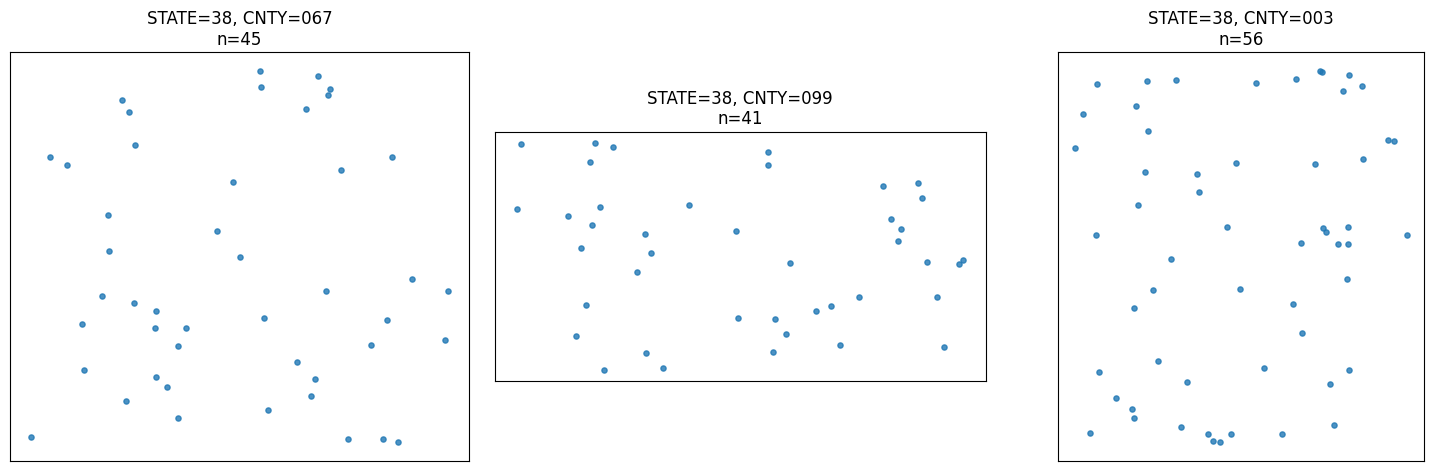

,STATEFIPS,CNTYFIPS,n_fields,density_score,mean_nn_km,n_cases,high_confidence,medium_confidence,low_confidence,difficult_cases,demo_score
0,38,067,45,0.007126,6.135735,45,18,11,17,33,0.840566
1,38,099,41,0.006531,6.701482,41,12,15,14,24,0.796226
2,38,003,56,0.006552,6.908614,56,6,27,23,6,0.775472


In [20]:
# Visual validation for top-3 county candidates (compactness check)
import matplotlib.pyplot as plt

if "COUNTY_DEMO_RANKING" not in globals() or COUNTY_DEMO_RANKING.empty:
    print("Run the previous county ranking cell first.")
else:
    top3 = COUNTY_DEMO_RANKING.head(3).copy()
    TOP3_DEMO_COUNTIES = top3[["STATEFIPS", "CNTYFIPS"]].astype(str).apply(tuple, axis=1).tolist()

    plot_df = COUNTY_BASE_POINTS_GDF.copy()
    plot_df["STATEFIPS"] = plot_df["STATEFIPS"].astype(str)
    plot_df["CNTYFIPS"] = plot_df["CNTYFIPS"].astype(str)

    fig, axes = plt.subplots(1, len(TOP3_DEMO_COUNTIES), figsize=(5 * len(TOP3_DEMO_COUNTIES), 4.6), constrained_layout=True)
    if len(TOP3_DEMO_COUNTIES) == 1:
        axes = [axes]

    for ax, (st, ct) in zip(axes, TOP3_DEMO_COUNTIES):
        one = plot_df[(plot_df["STATEFIPS"] == st) & (plot_df["CNTYFIPS"] == ct)]
        if one.empty:
            ax.set_title(f"{st}-{ct} (no points)")
            ax.axis("off")
            continue

        x = one.geometry.x.values
        y = one.geometry.y.values
        ax.scatter(x, y, s=14, alpha=0.8)
        ax.set_title(f"STATE={st}, CNTY={ct}\nn={len(one)}")
        ax.set_aspect("equal", adjustable="box")
        ax.set_xticks([])
        ax.set_yticks([])

    plt.show()

    display(top3[[
        "STATEFIPS", "CNTYFIPS", "n_fields", "density_score", "mean_nn_km",
        "n_cases", "high_confidence", "medium_confidence", "low_confidence",
        "difficult_cases", "demo_score"
    ]])

### Case review and explainability panels
В этом блоке есть два последовательных шага:
1. `Case Selection Panel`: выбрать кейс и посмотреть его табличные детали (`top-k`, confidence, graph alignment).
2. `Graph Panel`: отдельно построить локальный explainability-граф для выбранного `CSBID`.

Если `ipywidgets` недоступен, используется fallback через переменную `SELECTED_CASE_CSBID`.

In [21]:
def show_case_details(csbid: str, cases_df: pd.DataFrame, candidates_df: pd.DataFrame):
    csbid_norm = normalize_csbid(csbid)
    one = cases_df[cases_df["CSBID"].astype(str).map(normalize_csbid) == csbid_norm]
    if one.empty:
        print(f"Case not found for CSBID={csbid}")
        return None

    case_row = one.iloc[0]
    cand = candidates_df[candidates_df["CSBID"].astype(str).map(normalize_csbid) == csbid_norm].copy()
    cand = cand.sort_values(["candidate_rank", "score"], ascending=[True, False])

    summary_md = [
        f"### Field Case {case_row['CSBID']}",
        f"History: {case_row['history_1']} -> {case_row['history_2']} -> {case_row['history_3']}",
        f"True target: {case_row['true_target']}",
        f"Top-1 candidate: {case_row['top1_candidate']} ({float(case_row['top1_score']):.3f})",
        f"Confidence bucket: {case_row['confidence_bucket']}",
        f"Graph alignment: {case_row['top1_graph_alignment']}",
        f"Interpretation: {case_row['case_interpretation']}",
    ]
    print("\n".join(summary_md))
    display(cand)
    return case_row, cand


def _build_case_options(cases_df: pd.DataFrame) -> List[str]:
    if cases_df is None or cases_df.empty:
        return []
    return [str(x) for x in cases_df["CSBID"].dropna().astype(str).tolist()]


case_options = _build_case_options(demo_cases_df)
if not case_options:
    print("No demo cases available for selector")
else:
    SELECTED_CASE_CSBID = str(globals().get("SELECTED_CASE_CSBID", case_options[0]))
    if SELECTED_CASE_CSBID not in case_options:
        SELECTED_CASE_CSBID = case_options[0]

    try:
        widgets = importlib.import_module("ipywidgets")
        CASE_SELECTOR = widgets.Dropdown(
            options=case_options,
            value=SELECTED_CASE_CSBID,
            description="Case:",
            layout=widgets.Layout(width="420px"),
        )

        CASE_DETAILS_OUT = widgets.Output(
            layout=widgets.Layout(border="1px solid #d0d7de", padding="8px", min_height="220px")
        )

        def _render_case_details(change=None):
            global SELECTED_CASE_CSBID
            SELECTED_CASE_CSBID = str(CASE_SELECTOR.value)
            with CASE_DETAILS_OUT:
                CASE_DETAILS_OUT.clear_output(wait=True)
                _ = show_case_details(SELECTED_CASE_CSBID, demo_cases_df, demo_candidates_df)

        if "_CASE_DETAILS_HANDLER" in globals() and "CASE_SELECTOR" in globals():
            try:
                CASE_SELECTOR.unobserve(_CASE_DETAILS_HANDLER, names="value")
            except Exception:
                pass

        _CASE_DETAILS_HANDLER = _render_case_details
        CASE_SELECTOR.observe(_CASE_DETAILS_HANDLER, names="value")
        _render_case_details()

        display(
            widgets.VBox([
                widgets.HTML("<b>Case Selection Panel</b>"),
                CASE_SELECTOR,
                CASE_DETAILS_OUT,
            ])
        )
    except ModuleNotFoundError:
        print("ipywidgets not installed; using variable-based selection.")
        print("Set SELECTED_CASE_CSBID to any value from this list and re-run this cell:")
        print(", ".join(case_options[:30]))
        _ = show_case_details(SELECTED_CASE_CSBID, demo_cases_df, demo_candidates_df)

Graph panel for selected case: 381724001648754


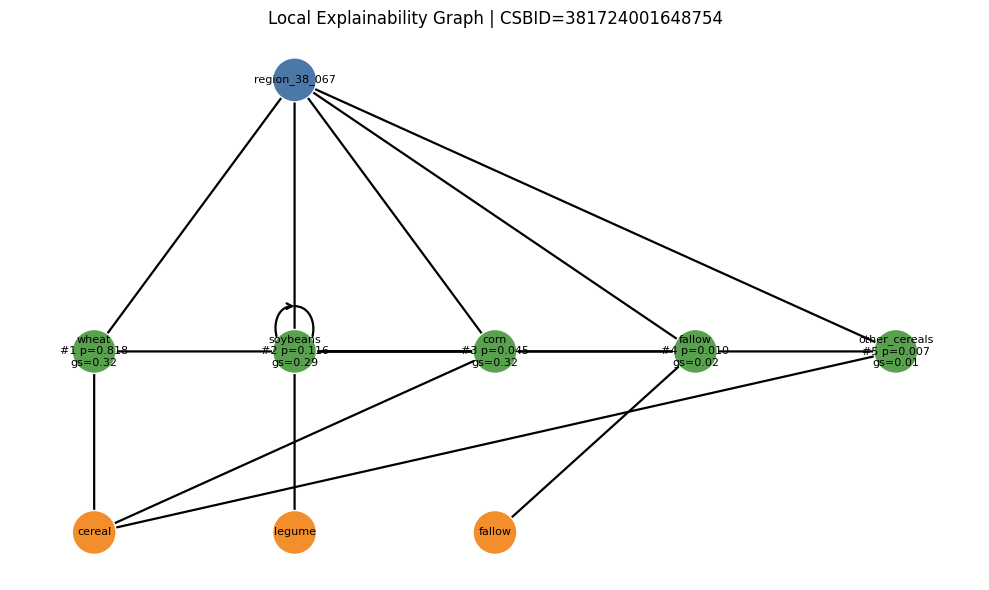

Use SELECTED_CASE_CSBID=<CSBID> in previous cell, then re-run this graph cell.


In [22]:
def plot_local_explainability_graph(csbid: str, cases_df: pd.DataFrame, candidates_df: pd.DataFrame):
    nx = importlib.import_module("networkx")
    plt = importlib.import_module("matplotlib.pyplot")

    csbid_norm = normalize_csbid(csbid)
    one = cases_df[cases_df["CSBID"].astype(str).map(normalize_csbid) == csbid_norm]
    if one.empty:
        print(f"No case for CSBID={csbid}")
        return

    case_row = one.iloc[0]
    cdf = candidates_df[candidates_df["CSBID"].astype(str).map(normalize_csbid) == csbid_norm].copy()
    if cdf.empty:
        print(f"No candidate-level rows for CSBID={csbid}")
        return

    G = nx.DiGraph()
    region_id = make_region_id(case_row.get("STATEFIPS"), case_row.get("CNTYFIPS"))
    last_crop = str(case_row.get("history_3"))
    last_crop_id = f"crop_{last_crop}"

    G.add_node(region_id, node_type="Region", label=region_id)
    G.add_node(last_crop_id, node_type="Crop", label=f"last:{last_crop}")

    for r in cdf.sort_values("candidate_rank").itertuples(index=False):
        cand = str(r.candidate)
        cand_id = f"crop_{cand}"
        group_id = f"group_{CROP_TO_GROUP.get(cand, 'unknown')}"

        G.add_node(cand_id, node_type="Crop", label=f"{cand}\n#{int(r.candidate_rank)} p={float(r.score):.3f}\ngs={float(r.graph_support_score):.2f}")
        G.add_node(group_id, node_type="CropGroup", label=CROP_TO_GROUP.get(cand, "unknown"))
        G.add_edge(cand_id, group_id, edge_type="belongs_to_group")
        G.add_edge(last_crop_id, cand_id, edge_type="follows_after")
        G.add_edge(region_id, cand_id, edge_type="common_in_region")

    pos = {}
    pos[region_id] = (0.0, 2.0)
    pos[last_crop_id] = (-2.2, 1.2)

    cand_nodes = [f"crop_{str(c)}" for c in cdf.sort_values("candidate_rank")["candidate"].tolist()]
    for i, node in enumerate(cand_nodes):
        pos[node] = (-1.2 + i * 1.2, 0.2)

    grp_nodes = [n for n, d in G.nodes(data=True) if d.get("node_type") == "CropGroup"]
    for i, node in enumerate(grp_nodes):
        pos[node] = (-1.2 + i * 1.2, -1.0)

    colors = []
    labels = {}
    for n, d in G.nodes(data=True):
        labels[n] = d.get("label", n)
        if d.get("node_type") == "Region":
            colors.append("#4C78A8")
        elif d.get("node_type") == "Crop":
            colors.append("#59A14F")
        else:
            colors.append("#F28E2B")

    plt.figure(figsize=(10, 6))
    nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=1000, edgecolors="#ffffff")
    nx.draw_networkx_edges(G, pos, arrows=True, arrowstyle="->", width=1.6)
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=8)
    plt.title(f"Local Explainability Graph | CSBID={case_row['CSBID']}")
    plt.axis("off")
    plt.tight_layout()
    plt.show()


selected_csbid = str(globals().get("SELECTED_CASE_CSBID", demo_cases_df.iloc[0]["CSBID"])) if not demo_cases_df.empty else None

if selected_csbid is None:
    print("No demo cases available for graph panel")
else:
    print(f"Graph panel for selected case: {selected_csbid}")
    plot_local_explainability_graph(selected_csbid, demo_cases_df, demo_candidates_df)
    print("Use SELECTED_CASE_CSBID=<CSBID> in previous cell, then re-run this graph cell.")

## 6) Logging and guarded diagnostics
Контролируемые сообщения и проверка, что все ключевые объекты пайплайна собраны корректно.

In [23]:
class DemoPipelineError(Exception):
    pass


def setup_logger(name: str = "spatial_demo") -> logging.Logger:
    logger = logging.getLogger(name)
    logger.setLevel(logging.INFO)
    if not logger.handlers:
        handler = logging.StreamHandler()
        handler.setLevel(logging.INFO)
        formatter = logging.Formatter("%(asctime)s | %(levelname)s | %(message)s")
        handler.setFormatter(formatter)
        logger.addHandler(handler)
    return logger


LOGGER = setup_logger()
LOGGER.info("Logger initialized")


def guarded_pipeline_summary() -> pd.DataFrame:
    try:
        needed = [
            ("demo_cases_df", "demo_cases_df" in globals()),
            ("demo_candidates_df", "demo_candidates_df" in globals()),
            ("GEO_DEMO_GDF", "GEO_DEMO_GDF" in globals()),
        ]
        miss = [name for name, ok in needed if not ok]
        if miss:
            raise DemoPipelineError(f"Missing required objects in runtime: {miss}")

        LOGGER.info("Core pipeline objects are available")
        return pd.DataFrame(
            [
                {"object": "demo_cases_df", "rows": len(demo_cases_df)},
                {"object": "demo_candidates_df", "rows": len(demo_candidates_df)},
                {"object": "geo_demo_gdf", "rows": len(GEO_DEMO_GDF)},
                {"object": "map_ready_in_runtime", "rows": int("DEMO_FOLIUM_MAP" in globals())},
            ]
        )
    except Exception as exc:
        LOGGER.error("Guarded summary failed: %s", exc)
        raise


display(guarded_pipeline_summary())

2026-04-21 21:25:19,267 | INFO | Logger initialized
2026-04-21 21:25:19,268 | INFO | Core pipeline objects are available


,object,rows
0,demo_cases_df,46
1,demo_candidates_df,230
2,geo_demo_gdf,46
3,map_ready_in_runtime,0


## 7) Sanity checks (без unit tests)
Короткие проверки целостности demo-таблиц, coverage и обязательных полей перед показом.

## 8) Map helper functions
Здесь определяются только вспомогательные функции для карты:
- форматирование popup/tooltip;
- нормализация confidence bucket;
- парсинг support/warning флагов;
- текстовая сборка explainability карточки.

In [24]:
import ast
import importlib
import re
from html import escape


CROP_COLOR_MAP = {
    "corn": "#E69F00",
    "soybeans": "#66A61E",
    "wheat": "#E6AB02",
    "sorghum": "#D95F02",
    "cotton": "#7570B3",
    "forage_hay": "#1B9E77",
    "fallow": "#A6761D",
    "legumes": "#66C2A5",
    "other_cereals": "#8DA0CB",
}

CONFIDENCE_LAYER_ORDER = ["high_confidence", "medium_confidence", "low_confidence"]
CONFIDENCE_LAYER_LABEL = {
    "high_confidence": "High confidence",
    "medium_confidence": "Medium confidence",
    "low_confidence": "Low confidence",
}

SUPPORT_FLAG_TEXT = {
    "region_typicality": "Candidate is common in the local region.",
    "legume_break_bonus": "Legume-break rule adds semantic support.",
    "fallow_break_effect": "Fallow-break effect supports this transition.",
}

WARNING_FLAG_TEXT = {
    "repeat_crop_warning": "Candidate repeats the previous crop and may reduce rotation diversity.",
    "same_group_saturation": "Same-group continuation may reduce diversity.",
    "fallow_break_effect": "Fallow-break effect is flagged as a caution for this case.",
}


def _safe_text(v: Any, fallback: str) -> str:
    if v is None:
        return fallback
    s = str(v).strip()
    if (not s) or s.lower() in {"none", "nan"}:
        return fallback
    return s


def _normalize_bucket(value: Any) -> str:
    s = str(value).strip().lower()
    if s in {"high_confidence", "high"}:
        return "high_confidence"
    if s in {"medium_confidence", "medium", "mid"}:
        return "medium_confidence"
    return "low_confidence"


def _format_bucket_label(value: Any) -> str:
    b = _normalize_bucket(value)
    return CONFIDENCE_LAYER_LABEL.get(b, b)


def _parse_list_like(value: Any) -> List[str]:
    if value is None:
        return []
    if isinstance(value, (list, tuple, set)):
        return [str(x) for x in value if str(x).strip()]

    s = str(value).strip()
    if not s:
        return []

    if s.startswith("[") and s.endswith("]"):
        try:
            parsed = ast.literal_eval(s)
            if isinstance(parsed, (list, tuple, set)):
                return [str(x) for x in parsed if str(x).strip()]
        except Exception:
            pass

    if "|" in s:
        return [p.strip() for p in s.split("|") if p.strip()]

    if "," in s:
        return [p.strip() for p in s.split(",") if p.strip()]

    return [s]


def _extract_flags_from_short_explanation(explanation: str) -> Tuple[List[str], List[str]]:
    if not explanation:
        return [], []

    support_flags: List[str] = []
    warning_flags: List[str] = []

    support_match = re.search(r"support\s*=\s*(\[[^\]]*\])", explanation)
    warning_match = re.search(r"warnings?\s*=\s*(\[[^\]]*\])", explanation)

    if support_match:
        support_flags = _parse_list_like(support_match.group(1))
    if warning_match:
        warning_flags = _parse_list_like(warning_match.group(1))

    return support_flags, warning_flags


def _humanize_flags(flags: List[str], mapping: Dict[str, str]) -> str:
    if not flags:
        return "None"

    phrases = [mapping.get(f, f.replace("_", " ")) for f in flags]
    return " ".join(phrases)


def _clean_short_explanation_text(text: str) -> str:
    if not text:
        return "Explanation is unavailable for this case."

    cleaned = re.sub(r";\s*support\s*=\s*\[[^\]]*\]", "", text, flags=re.IGNORECASE)
    cleaned = re.sub(r";\s*warnings?\s*=\s*\[[^\]]*\]", "", cleaned, flags=re.IGNORECASE)
    return cleaned.strip(" ;") if cleaned.strip(" ;") else "Explanation is unavailable for this case."


def _format_top3(value: Any) -> str:
    items = _parse_list_like(value)
    return " | ".join(items) if items else "n/a"


def make_popup_html(row: pd.Series) -> str:
    history = " -> ".join([
        _safe_text(row.get("history_1"), "?"),
        _safe_text(row.get("history_2"), "?"),
        _safe_text(row.get("history_3"), "?"),
    ])

    graph_alignment = _safe_text(row.get("top1_graph_alignment"), "unknown")
    short_expl_raw = _safe_text(row.get("short_explanation_top1"), "")
    case_interpretation = _safe_text(row.get("case_interpretation"), "Case interpretation is unavailable.")

    support_flags, warning_flags = _extract_flags_from_short_explanation(short_expl_raw)
    support_text = _humanize_flags(support_flags, SUPPORT_FLAG_TEXT)
    warning_text = _humanize_flags(warning_flags, WARNING_FLAG_TEXT)

    short_expl_clean = _clean_short_explanation_text(short_expl_raw)
    top3_str = _format_top3(row.get("top3_candidates"))

    csbid = escape(_safe_text(row.get("CSBID"), "unknown"))
    true_target = escape(_safe_text(row.get("true_target"), "unknown"))
    top1_candidate = escape(_safe_text(row.get("top1_candidate"), "unknown"))
    confidence_label = escape(_format_bucket_label(row.get("confidence_bucket")))

    top1_score = pd.to_numeric(pd.Series([row.get("top1_score")]), errors="coerce").fillna(0.0).iloc[0]

    return (
        "<div style='font-family:Segoe UI,Arial,sans-serif;font-size:12px;line-height:1.4;"
        "min-width:320px;max-width:360px;padding:4px 2px;'>"
        f"<div style='font-weight:700;font-size:13px;margin-bottom:6px;'>Field {csbid}</div>"
        f"<b>History:</b> {escape(history)}<br>"
        f"<b>True target:</b> {true_target}<br>"
        f"<b>Top-1:</b> {top1_candidate} ({float(top1_score):.3f})<br>"
        f"<b>Top-3:</b> {escape(top3_str)}<br>"
        f"<b>Confidence:</b> {confidence_label}<br>"
        f"<b>Graph alignment:</b> {escape(graph_alignment)}"
        "<hr style='margin:6px 0;border:none;border-top:1px solid #dddddd;'>"
        f"<b>Explanation:</b> {escape(short_expl_clean)}<br>"
        f"<b>Support:</b> {escape(support_text)}<br>"
        f"<b>Cautions:</b> {escape(warning_text)}<br>"
        f"<b>Case note:</b> {escape(case_interpretation)}"
        "</div>"
    )


def filter_map_dataset(gdf: Any, county: Optional[str] = None, confidence_bucket: Optional[str] = None, predicted_class: Optional[str] = None):
    out = gdf.copy()
    if county is not None and "CNTYFIPS" in out.columns:
        out = out[out["CNTYFIPS"].astype(str) == str(county)]
    if confidence_bucket is not None and "confidence_bucket" in out.columns:
        out = out[out["confidence_bucket"].map(_normalize_bucket) == _normalize_bucket(confidence_bucket)]
    if predicted_class is not None and "top1_candidate" in out.columns:
        out = out[out["top1_candidate"].astype(str) == str(predicted_class)]
    return out

### Map layout and rendering helpers
В этом блоке:
- готовится двухслойная карта: polygon filtered 9-class county context + highlighted demo cases;
- фоновый context layer строится targeted-read по CSBID из `.gdb` и кэшируется как polygon parquet;
- demo layer сохраняет popup, tooltip и связь с graph panel;
- confidence остаётся в tooltip/popup, но отдельные confidence-переключатели карты не создаются;
- описываются стили слоёв, легенда и функция `build_folium_map(...)` без запуска экспорта.


In [25]:
def _is_difficult_case(df: pd.DataFrame) -> pd.Series:
    alignment = df.get("top1_graph_alignment", pd.Series(index=df.index, dtype="object")).astype(str).str.lower()
    interpretation = df.get("case_interpretation", pd.Series(index=df.index, dtype="object")).astype(str).str.lower()
    return alignment.eq("weak") | interpretation.str.contains("difficult|low-confidence|weak-support", regex=True, na=False)


def _take_diverse_subset(df: pd.DataFrame, max_items: int) -> pd.DataFrame:
    if df.empty:
        return df

    max_items = int(max(1, min(max_items, len(df))))
    work = df.copy()
    work["_score"] = pd.to_numeric(work.get("top1_score"), errors="coerce").fillna(0.0)
    work["_bucket"] = work.get("confidence_bucket", "low_confidence").map(_normalize_bucket)
    work["_difficult"] = _is_difficult_case(work)

    picked: List[int] = []

    difficult_quota = min(max(2, max_items // 4), max_items)
    difficult = work[work["_difficult"]].sort_values("_score", ascending=False).head(difficult_quota)
    picked.extend(difficult.index.tolist())

    remaining = max_items - len(picked)
    per_bucket_quota = max(1, remaining // 3) if remaining > 0 else 0

    for bucket in CONFIDENCE_LAYER_ORDER:
        if remaining <= 0:
            break
        cand = (
            work[(work["_bucket"] == bucket) & (~work.index.isin(picked))]
            .sort_values("_score", ascending=False)
            .head(min(per_bucket_quota, remaining))
        )
        picked.extend(cand.index.tolist())
        remaining = max_items - len(picked)

    if remaining > 0:
        fill = work[~work.index.isin(picked)].sort_values("_score", ascending=False).head(remaining)
        picked.extend(fill.index.tolist())

    out = work.loc[picked].copy()
    return out.drop(columns=["_score", "_bucket", "_difficult"], errors="ignore")


def _resolve_county_column(df: pd.DataFrame) -> Optional[str]:
    direct = ["CNTYFIPS", "CNTYFIPS_geo", "CNTYFIPS_meta", "CNTYFIPS_x", "CNTYFIPS_y"]
    for col in direct:
        if col in df.columns and df[col].notna().any():
            return col
    for col in df.columns:
        if "cntyfips" in str(col).lower() and df[col].notna().any():
            return str(col)
    return None


def select_spatial_cluster(gdf: Any, cluster_size: int = 30, max_radius_km: Optional[float] = 40.0):
    """Select a strictly local cluster around densest anchor, with optional radius cap."""
    if gdf is None or gdf.empty:
        return gdf

    cluster_size = int(max(1, min(cluster_size, len(gdf))))
    full = gdf.copy()
    work = full.copy()

    selected_county = None
    county_col = _resolve_county_column(work)
    if county_col is not None:
        county_counts = work[county_col].astype(str).value_counts()
        if not county_counts.empty:
            selected_county = str(county_counts.idxmax())
            work_county = work[work[county_col].astype(str) == selected_county].copy()
            if not work_county.empty:
                work = work_county

    # If county slice is too small, relax county filter but keep strict nearest-neighbor compactness.
    if len(work) < cluster_size:
        work = full.copy()

    metric = work.to_crs("EPSG:3857")
    cent = metric.geometry.centroid
    valid_mask = cent.notna() & (~cent.is_empty)
    if int(valid_mask.sum()) == 0:
        out = _take_diverse_subset(work, max_items=cluster_size)
        return out

    cent_valid = cent.loc[valid_mask]
    idx = cent_valid.index.to_numpy()
    coords = np.column_stack([cent_valid.x.values, cent_valid.y.values]).astype(float)

    if len(idx) == 1:
        return work.loc[idx].copy()

    # Pairwise distances to detect the densest local anchor area.
    delta = coords[:, None, :] - coords[None, :, :]
    dist_mx = np.sqrt((delta ** 2).sum(axis=2))

    k_density = int(max(2, min(cluster_size, len(idx))))
    kth_radius = np.partition(dist_mx, k_density - 1, axis=1)[:, k_density - 1]

    if "top1_score" in work.columns:
        score_vals = pd.to_numeric(work.loc[idx, "top1_score"], errors="coerce").fillna(0.0).to_numpy()
    else:
        score_vals = np.zeros(len(idx), dtype=float)

    # Prefer densest point, tie-break by model confidence.
    anchor_pos = int(np.argmin(kth_radius - 0.02 * score_vals))
    anchor_idx = idx[anchor_pos]
    anchor_dist = dist_mx[anchor_pos]

    nearest_pool_size = int(min(len(idx), cluster_size))
    nearest_order = np.argsort(anchor_dist)[:nearest_pool_size]
    nearest_idx = idx[nearest_order]

    candidate_pool = work.loc[nearest_idx].copy()
    candidate_pool["_anchor_dist"] = anchor_dist[nearest_order]
    candidate_pool = candidate_pool.sort_values("_anchor_dist", ascending=True)

    candidate_pool = candidate_pool.sort_values("_anchor_dist", ascending=True)

    selection_mode = "nearest_fallback"
    if max_radius_km is not None:
        radius_limit_m = float(max_radius_km) * 1000.0
        within_radius = candidate_pool[candidate_pool["_anchor_dist"] <= radius_limit_m].copy()
        if len(within_radius) > 0:
            clustered = within_radius.head(cluster_size).copy()
            selection_mode = "radius_strict"
        else:
            clustered = candidate_pool.head(cluster_size).copy()
    else:
        clustered = candidate_pool.head(cluster_size).copy()

    radius_km = float(clustered["_anchor_dist"].max() / 1000.0) if "_anchor_dist" in clustered.columns and not clustered.empty else None

    print("Spatial cluster for map:", {
        "selected_county": selected_county,
        "county_column": county_col,
        "anchor_csbid": str(work.loc[anchor_idx, "CSBID"]) if "CSBID" in work.columns else None,
        "candidate_pool": int(len(candidate_pool)),
        "final_size": int(len(clustered)),
        "selection_mode": selection_mode,
        "max_radius_km_limit": max_radius_km,
        "max_radius_km": None if radius_km is None else round(radius_km, 2),
    })

    return clustered.drop(columns=["_anchor_dist"], errors="ignore")


def _make_tooltip_text(row: pd.Series) -> str:
    csbid = _safe_text(row.get("CSBID"), "unknown")
    top1 = _safe_text(row.get("top1_candidate"), "unknown")
    conf = _format_bucket_label(row.get("confidence_bucket"))
    return f"CSBID: {csbid} | top1: {top1} | confidence: {conf}"


def _context_cache_path(config: DemoConfig, state: str, county: str, max_polygons: int) -> Path:
    cache_dir = getattr(config, "cache_dir", MAP_OUTPUT_DIR / "cache")
    cache_dir.mkdir(parents=True, exist_ok=True)
    return cache_dir / f"filtered_9class_context_polygons_state{state}_county{county}_n{int(max_polygons)}.parquet"


def _normalize_region_keys(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if "STATEFIPS" in out.columns:
        out["STATEFIPS"] = out["STATEFIPS"].astype(str).str.zfill(2)
    if "CNTYFIPS" in out.columns:
        out["CNTYFIPS"] = out["CNTYFIPS"].astype(str).str.zfill(3)
    if "CSBID" in out.columns:
        out["CSBID"] = out["CSBID"].astype(str).map(normalize_csbid)
    return out


def _sample_context_candidates(context_df: pd.DataFrame, demo_gdf: Any, max_polygons: int) -> pd.DataFrame:
    """Keep a compact, representative polygon context sample around the demo area."""
    max_polygons = int(max(1, max_polygons))
    if len(context_df) <= max_polygons:
        return context_df.copy()

    work = context_df.copy()
    if demo_gdf is not None and len(demo_gdf) > 0 and "INSIDE_X" in work.columns and "INSIDE_Y" in work.columns:
        demo_metric = demo_gdf.to_crs("EPSG:5070") if getattr(demo_gdf, "crs", None) is not None else demo_gdf
        demo_cent = demo_metric.geometry.centroid
        demo_x = float(demo_cent.x.mean())
        demo_y = float(demo_cent.y.mean())
        work["_dist_to_demo"] = np.sqrt((work["INSIDE_X"].astype(float) - demo_x) ** 2 + (work["INSIDE_Y"].astype(float) - demo_y) ** 2)
        nearest_n = int(max_polygons * 0.75)
        nearest = work.sort_values("_dist_to_demo", ascending=True).head(nearest_n)
        remaining_n = max_polygons - len(nearest)
        if remaining_n > 0:
            rest = work[~work["CSBID"].isin(set(nearest["CSBID"]))]
            if "target" in rest.columns and rest["target"].notna().any():
                broad = (
                    rest.groupby("target", group_keys=False)
                    .apply(lambda g: g.sample(n=min(len(g), max(1, int(np.ceil(remaining_n * len(g) / max(len(rest), 1))))), random_state=SEED))
                    .head(remaining_n)
                )
            else:
                broad = rest.sample(n=min(remaining_n, len(rest)), random_state=SEED)
            out = pd.concat([nearest, broad], ignore_index=True).drop_duplicates(subset=["CSBID"]).head(max_polygons)
        else:
            out = nearest
        return out.drop(columns=["_dist_to_demo"], errors="ignore").copy()

    if "target" in work.columns and work["target"].notna().any():
        return (
            work.groupby("target", group_keys=False)
            .apply(lambda g: g.sample(n=min(len(g), max(1, int(np.ceil(max_polygons * len(g) / max(len(work), 1))))), random_state=SEED))
            .head(max_polygons)
            .copy()
        )

    return work.sample(n=max_polygons, random_state=SEED).copy()


def build_filtered_context_gdf(config: DemoConfig, state: Optional[str], county: Optional[str], demo_gdf: Optional[Any] = None):
    """Build limited filtered 9-class county polygon context, cached for map reruns."""
    if state is None or county is None:
        return None

    state = str(state).zfill(2)
    county = str(county).zfill(3)
    max_polygons = int(getattr(config, "context_max_polygons", 2000))
    cache_path = _context_cache_path(config, state, county, max_polygons)

    gpd, _, _ = load_geospatial_modules()
    if cache_path.exists():
        try:
            context_gdf = gpd.read_parquet(cache_path)
            geom_types = set(context_gdf.geometry.geom_type.dropna().astype(str).tolist()) if "geometry" in context_gdf.columns else set()
            if geom_types & {"Polygon", "MultiPolygon"}:
                print("[INFO] Loaded filtered polygon context layer from cache:", cache_path)
                return context_gdf.to_crs(getattr(config, "target_epsg", "EPSG:4326"))
            print("[WARN] Context cache is not polygon geometry; rebuilding:", geom_types)
        except Exception as exc:
            print(f"[WARN] Failed to read filtered polygon context cache, rebuilding: {exc}")

    split_paths = [
        RESEARCH_CHECKPOINT_DIR / "baseline" / "train_df.pkl",
        RESEARCH_CHECKPOINT_DIR / "baseline" / "val_df.pkl",
        RESEARCH_CHECKPOINT_DIR / "baseline" / "test_df.pkl",
    ]
    required_cols = ["CSBID", "STATEFIPS", "CNTYFIPS", "INSIDE_X", "INSIDE_Y", "target"]
    parts = []
    for path in split_paths:
        if not path.exists():
            print("[WARN] Missing split artifact for context layer:", path)
            continue
        df = pd.read_pickle(path)
        missing = sorted(set(required_cols) - set(df.columns))
        if missing:
            print(f"[WARN] Context layer skipped {path.name}; missing columns: {missing}")
            continue
        df = _normalize_region_keys(df[required_cols])
        part = df[(df["STATEFIPS"] == state) & (df["CNTYFIPS"] == county)].copy()
        if not part.empty:
            parts.append(part)

    if not parts:
        print("[WARN] No rows for filtered 9-class context layer", {"state": state, "county": county})
        return None

    context_df_full = (
        pd.concat(parts, ignore_index=True)
        .dropna(subset=["CSBID", "INSIDE_X", "INSIDE_Y"])
        .drop_duplicates(subset=["CSBID"])
        .copy()
    )
    context_df = _sample_context_candidates(context_df_full, demo_gdf=demo_gdf, max_polygons=max_polygons)
    print("Filtered polygon context sample:", {
        "full_filtered_fields": int(len(context_df_full)),
        "sampled_for_polygons": int(len(context_df)),
        "context_max_polygons": int(max_polygons),
    })
    target_ids = set(context_df["CSBID"].astype(str).map(normalize_csbid).dropna())

    context_polygons = None
    if "load_field_geodata_fast" in globals() and callable(load_field_geodata_fast):
        try:
            context_polygons, context_meta = load_field_geodata_fast(
                config=config,
                columns=["CSBID", "STATEFIPS", "CNTYFIPS"],
                target_csbids=target_ids,
            )
            print("[INFO] Filtered context polygon read meta:", context_meta)
        except Exception as exc:
            print(f"[WARN] Filtered context polygon read failed: {exc}")

    if context_polygons is None or context_polygons.empty:
        raise ValueError("Filtered context polygon layer could not be built. Re-run after geodata helpers are available.")

    if "CSBID_norm" not in context_polygons.columns and "CSBID" in context_polygons.columns:
        context_polygons["CSBID_norm"] = context_polygons["CSBID"].astype(str).map(normalize_csbid)
    context_df["CSBID_norm"] = context_df["CSBID"].astype(str).map(normalize_csbid)

    keep_geo_cols = [c for c in ["CSBID_norm", "CSBID", "STATEFIPS", "CNTYFIPS", "geometry"] if c in context_polygons.columns]
    context_polygons = context_polygons[keep_geo_cols].drop_duplicates(subset=["CSBID_norm"]).copy()
    context_gdf = context_polygons.merge(
        context_df[["CSBID_norm", "target"]].drop_duplicates(subset=["CSBID_norm"]),
        on="CSBID_norm",
        how="left",
    )
    context_gdf = gpd.GeoDataFrame(context_gdf, geometry="geometry", crs=context_polygons.crs)
    context_gdf = context_gdf.to_crs(getattr(config, "target_epsg", "EPSG:4326"))

    geom_types = set(context_gdf.geometry.geom_type.dropna().astype(str).tolist())
    if not (geom_types & {"Polygon", "MultiPolygon"}):
        raise ValueError(f"Filtered context layer is not polygon geometry: {sorted(geom_types)}")

    try:
        context_gdf.to_parquet(cache_path, index=False)
        print("[INFO] Saved filtered polygon context layer cache:", cache_path)
    except Exception as exc:
        print(f"[WARN] Failed to save filtered polygon context cache: {exc}")

    return context_gdf


def _add_context_layer(folium_module: Any, fmap: Any, context_gdf: Any, demo_gdf: Any):
    if context_gdf is None or len(context_gdf) == 0:
        return None

    context = context_gdf.copy()
    if getattr(context, "crs", None) is not None and str(context.crs).upper() != "EPSG:4326":
        context = context.to_crs("EPSG:4326")

    demo_ids = set()
    if demo_gdf is not None and "CSBID" in demo_gdf.columns:
        demo_ids = set(demo_gdf["CSBID"].astype(str).map(normalize_csbid))
    if "CSBID" in context.columns and demo_ids:
        context["CSBID_norm"] = context["CSBID"].astype(str).map(normalize_csbid)
        context = context[~context["CSBID_norm"].isin(demo_ids)].copy()

    if context.empty:
        return None

    layer = folium_module.FeatureGroup(
        name=f"Spatial context: filtered 9-class fields ({len(context):,})",
        show=True,
        control=True,
    )

    for _, row in context.iterrows():
        geom = row.geometry
        geom_type = getattr(geom, "geom_type", None)
        if geom_type in {"Polygon", "MultiPolygon"}:
            folium_module.GeoJson(
                data=geom.__geo_interface__,
                style_function=lambda _x: {
                    "fillColor": "#C8D0D7",
                    "color": "#8E99A3",
                    "weight": 0.35,
                    "fillOpacity": 0.18,
                },
                highlight_function=lambda _x: {"weight": 0.7, "fillOpacity": 0.26},
            ).add_to(layer)
        else:
            pt = geom.centroid if hasattr(geom, "centroid") else geom
            folium_module.CircleMarker(
                location=[float(pt.y), float(pt.x)],
                radius=2,
                color="#7A8288",
                weight=0.35,
                opacity=0.32,
                fill=True,
                fill_color="#B8C0C7",
                fill_opacity=0.18,
            ).add_to(layer)

    layer.add_to(fmap)
    return layer


def _make_popup_html_for_map(row: pd.Series) -> str:
    csbid = _safe_text(row.get("CSBID"), "unknown")
    base = make_popup_html(row)
    return (
        f"<div class='case-popup-root' data-csbid='{escape(csbid)}'>"
        f"{base}"
        f"<div style='margin-top:8px;'><button onclick=\"window.showCaseGraph('{escape(csbid)}')\" style='padding:5px 9px;border:1px solid #9aa4ae;background:#f8fafc;border-radius:4px;cursor:pointer;font-size:12px;'>Open graph panel</button></div>"
        "</div>"
    )


def _add_feature_to_layer(folium_module: Any, feature_layer: Any, row: pd.Series, color: str, fill_opacity: float):
    popup_html = _make_popup_html_for_map(row)
    tooltip_text = _make_tooltip_text(row)

    geom = row.geometry
    geom_type = getattr(geom, "geom_type", None)

    if geom_type in {"Polygon", "MultiPolygon"}:
        gj = folium_module.GeoJson(
            data=geom.__geo_interface__,
            style_function=lambda _x, c=color, fo=fill_opacity: {
                "fillColor": c,
                "color": "#1f2933",
                "weight": 1.15,
                "fillOpacity": fo,
            },
            highlight_function=lambda _x: {"weight": 2.0, "fillOpacity": min(fill_opacity + 0.18, 1.0)},
            tooltip=folium_module.Tooltip(tooltip_text),
        )
        gj.add_child(folium_module.Popup(popup_html, max_width=430))
        gj.add_to(feature_layer)
    else:
        pt = geom.centroid if hasattr(geom, "centroid") else geom
        folium_module.CircleMarker(
            location=[float(pt.y), float(pt.x)],
            radius=6,
            color="#1f2933",
            weight=1.3,
            fill=True,
            fill_opacity=min(fill_opacity + 0.2, 1.0),
            fill_color=color,
            tooltip=tooltip_text,
            popup=folium_module.Popup(popup_html, max_width=430),
        ).add_to(feature_layer)


def _build_case_graph_payload(cases_df: pd.DataFrame, candidates_df: pd.DataFrame, csbid_list: List[str]) -> Dict[str, Dict[str, str]]:
    import io
    import base64

    nx = importlib.import_module("networkx")
    plt = importlib.import_module("matplotlib.pyplot")

    payload: Dict[str, Dict[str, str]] = {}

    for csbid in csbid_list:
        csbid_norm = normalize_csbid(csbid)
        one = cases_df[cases_df["CSBID"].astype(str).map(normalize_csbid) == csbid_norm]
        cdf = candidates_df[candidates_df["CSBID"].astype(str).map(normalize_csbid) == csbid_norm].copy()

        if one.empty or cdf.empty:
            payload[str(csbid)] = {
                "title": f"CSBID {csbid}",
                "history": "n/a",
                "image": "",
                "note": "Graph data is unavailable for this field.",
            }
            continue

        case_row = one.iloc[0]
        cdf = cdf.sort_values("candidate_rank")

        G = nx.DiGraph()
        region_id = make_region_id(case_row.get("STATEFIPS"), case_row.get("CNTYFIPS"))
        last_crop = str(case_row.get("history_3"))
        last_crop_id = f"crop_{last_crop}"

        G.add_node(region_id, node_type="Region", label=region_id)
        G.add_node(last_crop_id, node_type="Crop", label=f"last:{last_crop}")

        for r in cdf.itertuples(index=False):
            cand = str(r.candidate)
            cand_id = f"crop_{cand}"
            group_id = f"group_{CROP_TO_GROUP.get(cand, 'unknown')}"
            G.add_node(cand_id, node_type="Crop", label=f"{cand}\n#{int(r.candidate_rank)} p={float(r.score):.3f}\ngs={float(r.graph_support_score):.2f}")
            G.add_node(group_id, node_type="CropGroup", label=CROP_TO_GROUP.get(cand, "unknown"))
            G.add_edge(cand_id, group_id, edge_type="belongs_to_group")
            G.add_edge(last_crop_id, cand_id, edge_type="follows_after")
            G.add_edge(region_id, cand_id, edge_type="common_in_region")

        pos = {region_id: (0.0, 2.0), last_crop_id: (-2.2, 1.2)}
        cand_nodes = [f"crop_{str(c)}" for c in cdf["candidate"].tolist()]
        for i, node in enumerate(cand_nodes):
            pos[node] = (-1.2 + i * 1.2, 0.2)

        grp_nodes = [n for n, d in G.nodes(data=True) if d.get("node_type") == "CropGroup"]
        for i, node in enumerate(grp_nodes):
            pos[node] = (-1.2 + i * 1.2, -1.0)

        colors = []
        labels = {}
        for n, d in G.nodes(data=True):
            labels[n] = d.get("label", n)
            if d.get("node_type") == "Region":
                colors.append("#4C78A8")
            elif d.get("node_type") == "Crop":
                colors.append("#59A14F")
            else:
                colors.append("#F28E2B")

        fig = plt.figure(figsize=(9.4, 6.0))
        nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=1120, edgecolors="#ffffff", linewidths=1.0)
        nx.draw_networkx_edges(G, pos, arrows=True, arrowstyle="->", width=1.6, alpha=0.78)
        nx.draw_networkx_labels(G, pos, labels=labels, font_size=8.5)
        plt.title(f"Local Explainability Graph | CSBID={case_row['CSBID']}")
        plt.axis("off")
        plt.tight_layout()

        buf = io.BytesIO()
        fig.savefig(buf, format="png", dpi=150, bbox_inches="tight")
        plt.close(fig)
        img_b64 = base64.b64encode(buf.getvalue()).decode("ascii")

        history = f"{case_row.get('history_1')} -> {case_row.get('history_2')} -> {case_row.get('history_3')}"
        payload[str(case_row["CSBID"])] = {
            "title": f"CSBID {case_row['CSBID']}",
            "history": history,
            "image": img_b64,
            "note": f"Top-1: {case_row.get('top1_candidate')} ({float(case_row.get('top1_score', 0.0)):.3f}) | confidence: {case_row.get('confidence_bucket')}",
        }

    return payload


def _inject_graph_side_panel(fmap: Any, graph_payload: Dict[str, Dict[str, str]]):
    import json

    folium = importlib.import_module("folium")
    map_name = fmap.get_name()
    payload_json = json.dumps(graph_payload, ensure_ascii=False)

    panel_html = """
    <div id='case-graph-panel' style='position: fixed; top: 14px; right: 14px; width: 46vw; min-width: 560px; max-width: 860px; max-height: 88vh; overflow:auto; z-index: 9999; background: rgba(255,255,255,0.97); border:1px solid #8b949e; border-radius:6px; padding:12px; box-shadow:0 4px 18px rgba(0,0,0,0.18); font-family:Segoe UI,Arial,sans-serif;'>
      <div style='font-weight:700;font-size:16px;margin-bottom:10px;'>Explainability Graph Panel</div>
      <div id='case-graph-title' style='font-size:13.5px;font-weight:600;margin-bottom:7px;color:#1f2933;'>Click a highlighted demo field to load the local graph</div>
      <div id='case-graph-note' style='font-size:12.5px;color:#4b5563;margin-bottom:12px;line-height:1.4;'></div>
      <img id='case-graph-image' style='width:100%;height:auto;display:none;border:1px solid #d0d7de;border-radius:4px;background:#ffffff;' />
    </div>
    """

    script = f"""
    <script>
    window.__caseGraphs = {payload_json};
    window.showCaseGraph = function(csbid) {{
      const panel = document.getElementById('case-graph-panel');
      const title = document.getElementById('case-graph-title');
      const note = document.getElementById('case-graph-note');
      const img = document.getElementById('case-graph-image');
      const d = window.__caseGraphs[String(csbid)];
      if (!d) {{
        title.textContent = 'No graph for CSBID ' + csbid;
        note.textContent = '';
        img.style.display = 'none';
        return;
      }}
      title.textContent = d.title + ' | ' + d.history;
      note.textContent = d.note || '';
      if (d.image) {{
        img.src = 'data:image/png;base64,' + d.image;
        img.style.display = 'block';
      }} else {{
        img.style.display = 'none';
      }}
      if (panel) {{ panel.scrollTop = 0; }}
    }};

    {map_name}.on('popupopen', function(e) {{
      try {{
        const el = e.popup.getElement();
        if (!el) return;
        const root = el.querySelector('.case-popup-root');
        if (!root) return;
        const csbid = root.getAttribute('data-csbid');
        if (csbid) window.showCaseGraph(csbid);
      }} catch (err) {{}}
    }});
    </script>
    """

    fmap.get_root().html.add_child(folium.Element(panel_html))
    fmap.get_root().html.add_child(folium.Element(script))


def build_folium_map(gdf: Any, config: DemoConfig, cases_df: pd.DataFrame, candidates_df: pd.DataFrame, context_gdf: Optional[Any] = None):
    folium = importlib.import_module("folium")

    if gdf.empty:
        raise ValueError("Cannot build map: empty GeoDataFrame")

    fit_source = context_gdf if context_gdf is not None and len(context_gdf) > 0 else gdf
    fit_source_wgs84 = fit_source.to_crs("EPSG:4326") if getattr(fit_source, "crs", None) is not None else fit_source
    fit_minx, fit_miny, fit_maxx, fit_maxy = fit_source_wgs84.total_bounds
    map_center = [float((fit_miny + fit_maxy) / 2.0), float((fit_minx + fit_maxx) / 2.0)]
    fmap = folium.Map(location=map_center, zoom_start=10, tiles=config.map_tiles, control_scale=True, prefer_canvas=True)

    _add_context_layer(folium, fmap, context_gdf, gdf)

    layer_all = folium.FeatureGroup(name=f"Demo cases: highlighted explainability fields ({len(gdf):,})", show=True)

    for _, row in gdf.iterrows():
        pred = _safe_text(row.get("top1_candidate"), "unknown")
        color = CROP_COLOR_MAP.get(pred, "#555555")
        _add_feature_to_layer(folium, layer_all, row, color, fill_opacity=0.76)

    layer_all.add_to(fmap)

    minx, miny, maxx, maxy = fit_source_wgs84.total_bounds
    fmap.fit_bounds([[float(miny), float(minx)], [float(maxy), float(maxx)]], padding=[18, 18])

    legend_rows = "".join(
        [
            f"<li style='margin:2px 0;display:flex;align-items:center;gap:6px;'><span style='background:{v};display:inline-block;width:10px;height:10px;border:1px solid #475569;'></span><span>{k}</span></li>"
            for k, v in CROP_COLOR_MAP.items()
        ]
    )
    context_n = 0 if context_gdf is None else int(len(context_gdf))
    legend_html = f"""
    <div style='position: fixed; bottom: 22px; left: 22px; z-index: 9999; background: rgba(255,255,255,0.96); border: 1px solid #8b949e; border-radius: 6px; padding: 9px 11px; font-family:Segoe UI,Arial,sans-serif; font-size: 11px; line-height:1.25; max-width: 230px; box-shadow:0 2px 10px rgba(0,0,0,0.12);'>
      <div style='font-weight:700; font-size:12px; margin-bottom:6px;'>Spatial demo layers</div>
      <div style='display:flex;align-items:center;gap:6px;margin-bottom:5px;'><span style='background:#B8C0C7;opacity:.55;display:inline-block;width:18px;height:8px;border:1px solid #7A8288;'></span><span>Filtered 9-class context fields ({context_n:,})</span></div>
      <div style='display:flex;align-items:center;gap:6px;margin-bottom:7px;'><span style='background:#111827;display:inline-block;width:18px;height:8px;border:2px solid #111827;'></span><span>Highlighted demo cases ({len(gdf):,})</span></div>
      <div style='font-weight:700; margin:6px 0 4px;'>Demo top-1 candidate</div>
      <ul style='list-style:none; padding:0; margin:0; columns:1;'>{legend_rows}</ul>
    </div>
    """
    fmap.get_root().html.add_child(folium.Element(legend_html))
    folium.LayerControl(collapsed=False, position="topright").add_to(fmap)

    graph_payload = _build_case_graph_payload(
        cases_df=cases_df,
        candidates_df=candidates_df,
        csbid_list=gdf["CSBID"].astype(str).tolist(),
    )
    _inject_graph_side_panel(fmap, graph_payload)
    return fmap


### Map build and export
Эта ячейка запускает готовые функции и создаёт финальный артефакт:
- применяет фильтры по county/cluster size для curated demo cases;
- собирает polygon filtered 9-class context layer для того же county;
- печатает контрольную сводку по выбранным слоям;
- строит двухслойную `DEMO_FOLIUM_MAP`;
- сохраняет HTML в `artifacts/results/recommendation`.


In [ ]:
DEMO_MAP_GDF = GEO_DEMO_GDF.copy()

if CONFIG.demo_county is not None and "CNTYFIPS" in DEMO_MAP_GDF.columns:
    DEMO_MAP_GDF = filter_map_dataset(DEMO_MAP_GDF, county=CONFIG.demo_county)
    print("Using explicit county from config:", CONFIG.demo_county)

if "CNTYFIPS" in DEMO_MAP_GDF.columns:
    print("Top counties in current demo subset:")
    display(
        DEMO_MAP_GDF["CNTYFIPS"].astype(str).value_counts().rename_axis("CNTYFIPS").reset_index(name="n_fields").head(8)
    )

cluster_size = getattr(CONFIG, "map_cluster_size", None)
if cluster_size is not None:
    cluster_size = int(cluster_size)
    before_n = len(DEMO_MAP_GDF)
    radius_km = getattr(CONFIG, "map_max_radius_km", 40.0)
    DEMO_MAP_GDF = select_spatial_cluster(DEMO_MAP_GDF, cluster_size=cluster_size, max_radius_km=radius_km)
    print("Applied map truncation:", {"before": before_n, "after": len(DEMO_MAP_GDF), "map_cluster_size": cluster_size})
else:
    print("Map truncation disabled (map_cluster_size=None). Using all selected fields:", len(DEMO_MAP_GDF))

print("Demo CSBID list (current map subset):")
print(", ".join(DEMO_MAP_GDF["CSBID"].astype(str).head(40).tolist()))

FILTERED_CONTEXT_GDF = build_filtered_context_gdf(
    CONFIG,
    state=getattr(CONFIG, "demo_state", None),
    county=getattr(CONFIG, "demo_county", None),
    demo_gdf=DEMO_MAP_GDF,
)
if FILTERED_CONTEXT_GDF is not None:
    print("Filtered 9-class spatial context layer:", FILTERED_CONTEXT_GDF.shape)

DEMO_FOLIUM_MAP = build_folium_map(DEMO_MAP_GDF, CONFIG, demo_cases_df, demo_candidates_df, context_gdf=FILTERED_CONTEXT_GDF)
map_out_path = MAP_OUTPUT_DIR / CONFIG.export_html_name
DEMO_FOLIUM_MAP.save(map_out_path.as_posix())
print("Saved map HTML:", map_out_path)
DEMO_FOLIUM_MAP


Using explicit county from config: 067
Top counties in current demo subset:


,CNTYFIPS,n_fields
0,067,46


Spatial cluster for map: {'selected_county': '067', 'county_column': 'CNTYFIPS', 'anchor_csbid': '381724004831243', 'candidate_pool': 20, 'final_size': 20, 'selection_mode': 'radius_strict', 'max_radius_km_limit': 40.0, 'max_radius_km': 28.01}
Applied map truncation: {'before': 46, 'after': 20, 'map_cluster_size': 20}
Demo CSBID list (current map subset):
381724004831243, 381724004831913, 381724004831241, 381724004830707, 381724004830394, 381724004832966, 381724004833304, 381724004830870, 381724004830143, 381724004828919, 381724002582008, 381724002581677, 381724004831144, 381724004828575, 381724004832744, 381724004320716, 381724001649861, 381724011151816, 381724001650155, 381724004320009
Filtered polygon context sample: {'full_filtered_fields': 16663, 'sampled_for_polygons': 2000, 'context_max_polygons': 2000}
[INFO] Skipping subset cache: targeted CSBID polygon mode enabled
[INFO] Trying targeted polygon read for 2000 CSBID values
[INFO] Targeted read ID columns: ['CSBID']


### 8.5) Spatial layer comparison: full region -> 9-class target space -> demo subset
Этот блок проверяет, на каком этапе возникает визуальное разрежение карты.

Сравниваются три слоя для текущего `CONFIG.demo_state` / `CONFIG.demo_county`:
- полный county-level слой из `dataset/national1724.pkl` без demo-отбора;
- тот же регион после перехода к рабочему 9-классовому target space baseline split;
- фактический `DEMO_MAP_GDF`, который используется в финальной HTML-карте.

,layer,n_fields,n_unique_CSBID,density_proxy,visual_comment,retention_note
0,full_region,19919,19919,2.708859,dense county coverage,100% reference layer
1,filtered_9_classes,16663,16663,2.288689,dense county coverage,83.7% of full-region fields retained
2,demo_subset,20,20,5.011598,dense county coverage,0.12% of filtered fields; 0.10% of full-region...


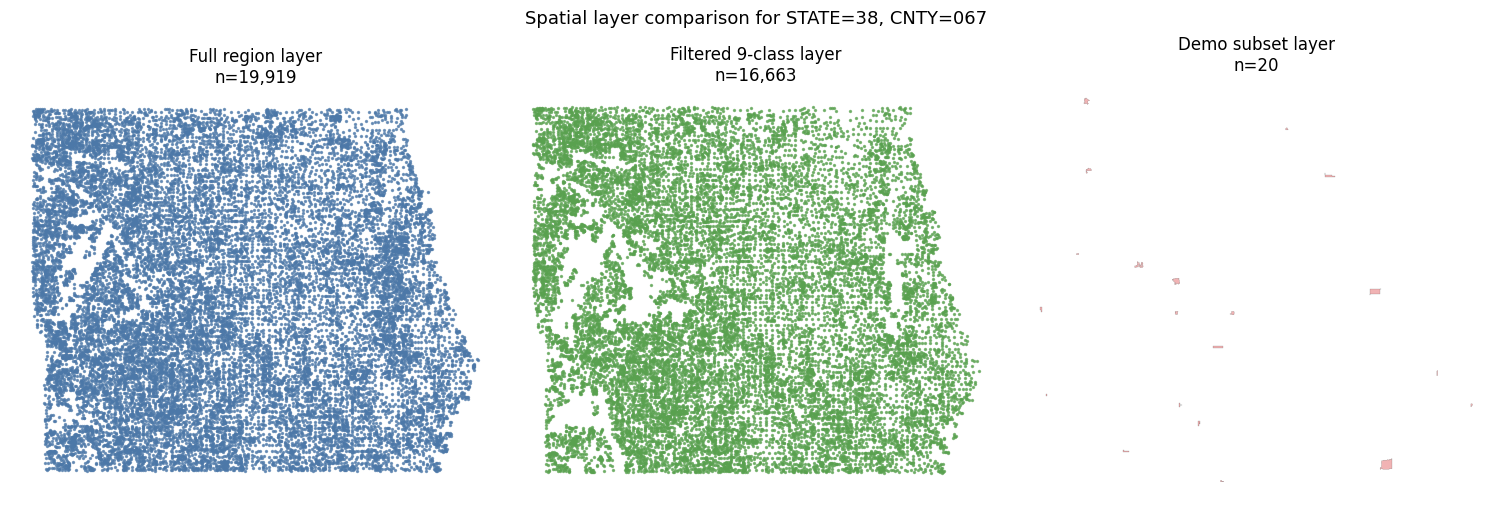

Saved comparison summary: C:\Users\Dmitry\code-projects\diploma-crop-rotation\artifacts\results\recommendation\spatial_layer_comparison_summary.csv
Saved comparison figure: C:\Users\Dmitry\code-projects\diploma-crop-rotation\artifacts\results\recommendation\spatial_layer_comparison.png
Layer comparison conclusion: filtered retention=83.7%; demo retention from filtered=0.12%. Основное разрежение возникает на этапе: demo selection / map truncation.


In [ ]:
# Spatial layer comparison: full county -> filtered target space -> actual demo map subset.
SPATIAL_COMPARISON_DIR = MAP_OUTPUT_DIR
SPATIAL_COMPARISON_SUMMARY_PATH = SPATIAL_COMPARISON_DIR / "spatial_layer_comparison_summary.csv"
SPATIAL_COMPARISON_FIG_PATH = SPATIAL_COMPARISON_DIR / "spatial_layer_comparison.png"

comparison_state = str(getattr(CONFIG, "demo_state", None) or "").zfill(2)
comparison_county = str(getattr(CONFIG, "demo_county", None) or "").zfill(3)
if not comparison_state.strip("0") or not comparison_county.strip("0"):
    raise ValueError("CONFIG.demo_state and CONFIG.demo_county must be set before spatial comparison")


def _region_norm_cols(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if "STATEFIPS" not in out.columns or "CNTYFIPS" not in out.columns:
        raise ValueError("Expected STATEFIPS and CNTYFIPS columns")
    out["STATEFIPS"] = out["STATEFIPS"].astype(str).str.zfill(2)
    out["CNTYFIPS"] = out["CNTYFIPS"].astype(str).str.zfill(3)
    if "CSBID" in out.columns:
        out["CSBID"] = out["CSBID"].astype(str).map(normalize_csbid)
    return out


def _filter_region(df: pd.DataFrame, state: str, county: str) -> pd.DataFrame:
    work = _region_norm_cols(df)
    return work[(work["STATEFIPS"] == state) & (work["CNTYFIPS"] == county)].copy()


def _points_gdf_from_inside_xy(df: pd.DataFrame, source_crs: str = "EPSG:5070"):
    gpd, _, _ = load_geospatial_modules()
    needed = {"CSBID", "INSIDE_X", "INSIDE_Y"}
    missing = sorted(needed - set(df.columns))
    if missing:
        raise ValueError(f"Missing columns for point geometry: {missing}")
    work = df.dropna(subset=["CSBID", "INSIDE_X", "INSIDE_Y"]).drop_duplicates(subset=["CSBID"]).copy()
    return gpd.GeoDataFrame(
        work,
        geometry=gpd.points_from_xy(work["INSIDE_X"], work["INSIDE_Y"]),
        crs=source_crs,
    )


def _read_full_region_layer(state: str, county: str):
    # This cache is the lightweight attribute mirror of the GDB layer and avoids a slow full .gdb scan.
    full_path = DATASET_DIR / "national1724.pkl"
    if not full_path.exists():
        raise FileNotFoundError(f"Full spatial attribute cache not found: {full_path}")
    full_df = pd.read_pickle(full_path)
    full_region = _filter_region(full_df, state, county)
    return _points_gdf_from_inside_xy(full_region, source_crs="EPSG:5070")


def _read_filtered_9class_region_layer(state: str, county: str):
    # Prefer the context layer already built for the two-layer map.
    if "FILTERED_CONTEXT_GDF" in globals() and FILTERED_CONTEXT_GDF is not None and len(FILTERED_CONTEXT_GDF) > 0:
        return FILTERED_CONTEXT_GDF.copy()

    # Baseline split artifacts are authoritative for the current 9-class target-space contract.
    split_paths = [
        RESEARCH_CHECKPOINT_DIR / "baseline" / "train_df.pkl",
        RESEARCH_CHECKPOINT_DIR / "baseline" / "val_df.pkl",
        RESEARCH_CHECKPOINT_DIR / "baseline" / "test_df.pkl",
    ]
    parts = []
    for path in split_paths:
        if not path.exists():
            print(f"[WARN] Missing split artifact: {path}")
            continue
        part = _filter_region(pd.read_pickle(path), state, county)
        if not part.empty:
            parts.append(part)
    if not parts:
        raise ValueError("No rows found for selected region in baseline split artifacts")
    filtered_region = pd.concat(parts, ignore_index=True).drop_duplicates(subset=["CSBID"])
    return _points_gdf_from_inside_xy(filtered_region, source_crs="EPSG:5070")


def _resolve_demo_map_layer(state: str, county: str):
    if "DEMO_MAP_GDF" in globals() and DEMO_MAP_GDF is not None and len(DEMO_MAP_GDF) > 0:
        demo = DEMO_MAP_GDF.copy()
    elif "GEO_DEMO_GDF" in globals() and GEO_DEMO_GDF is not None and len(GEO_DEMO_GDF) > 0:
        demo = GEO_DEMO_GDF.copy()
        if "CNTYFIPS" in demo.columns:
            demo = _filter_region(demo, state, county)
    else:
        raise ValueError("Run the geospatial merge/map cells before this comparison block")

    if "CSBID" in demo.columns:
        demo["CSBID"] = demo["CSBID"].astype(str).map(normalize_csbid)
    return demo.drop_duplicates(subset=["CSBID"]).copy() if "CSBID" in demo.columns else demo.copy()


def _layer_metrics(layer_name: str, gdf: Any) -> dict:
    if gdf is None or len(gdf) == 0:
        return {
            "layer": layer_name,
            "n_fields": 0,
            "n_unique_CSBID": 0,
            "bounds": None,
            "bounds_area_km2": np.nan,
            "area_proxy_km2": np.nan,
            "density_proxy": np.nan,
            "visual_comment": "empty layer",
        }

    metric = gdf.to_crs("EPSG:3857") if getattr(gdf, "crs", None) is not None else gdf.set_crs("EPSG:4326").to_crs("EPSG:3857")
    minx, miny, maxx, maxy = metric.total_bounds
    bounds_area_km2 = float(max(((maxx - minx) * (maxy - miny)) / 1_000_000.0, 0.01))

    geom_types = set(metric.geometry.geom_type.dropna().astype(str).tolist())
    polygon_like = bool(geom_types & {"Polygon", "MultiPolygon"})
    if polygon_like:
        geom_area_km2 = float(max(metric.geometry.area.sum() / 1_000_000.0, 0.01))
        area_proxy_km2 = geom_area_km2
    else:
        try:
            union_geom = metric.geometry.union_all() if hasattr(metric.geometry, "union_all") else metric.geometry.unary_union
            hull_area_km2 = float(max(union_geom.convex_hull.area / 1_000_000.0, 0.01))
        except Exception:
            hull_area_km2 = np.nan
        area_proxy_km2 = float(max(bounds_area_km2, hull_area_km2 if np.isfinite(hull_area_km2) else 0.0, 0.01))

    n_fields = int(len(gdf))
    n_unique = int(gdf["CSBID"].nunique()) if "CSBID" in gdf.columns else n_fields
    density = float(n_fields / area_proxy_km2) if area_proxy_km2 > 0 else np.nan
    bounds_wgs84 = gdf.to_crs("EPSG:4326").total_bounds if getattr(gdf, "crs", None) is not None else gdf.total_bounds
    bounds = tuple(round(float(v), 6) for v in bounds_wgs84)

    return {
        "layer": layer_name,
        "n_fields": n_fields,
        "n_unique_CSBID": n_unique,
        "bounds": bounds,
        "bounds_area_km2": round(bounds_area_km2, 3),
        "area_proxy_km2": round(area_proxy_km2, 3),
        "density_proxy": round(density, 6),
        "visual_comment": "dense county coverage" if density >= 1.0 else "sparse selected cases over county extent",
    }


FULL_REGION_GDF = _read_full_region_layer(comparison_state, comparison_county)
FILTERED_9CLASS_REGION_GDF = _read_filtered_9class_region_layer(comparison_state, comparison_county)
DEMO_SUBSET_COMPARISON_GDF = _resolve_demo_map_layer(comparison_state, comparison_county)

SPATIAL_LAYER_SUMMARY = pd.DataFrame([
    _layer_metrics("full_region", FULL_REGION_GDF),
    _layer_metrics("filtered_9_classes", FILTERED_9CLASS_REGION_GDF),
    _layer_metrics("demo_subset", DEMO_SUBSET_COMPARISON_GDF),
])

full_n = float(SPATIAL_LAYER_SUMMARY.loc[SPATIAL_LAYER_SUMMARY["layer"] == "full_region", "n_fields"].iloc[0])
filtered_n = float(SPATIAL_LAYER_SUMMARY.loc[SPATIAL_LAYER_SUMMARY["layer"] == "filtered_9_classes", "n_fields"].iloc[0])
demo_n = float(SPATIAL_LAYER_SUMMARY.loc[SPATIAL_LAYER_SUMMARY["layer"] == "demo_subset", "n_fields"].iloc[0])

filtered_retention = filtered_n / full_n if full_n else np.nan
demo_retention_from_filtered = demo_n / filtered_n if filtered_n else np.nan
demo_retention_from_full = demo_n / full_n if full_n else np.nan

SPATIAL_LAYER_SUMMARY["retention_note"] = [
    "100% reference layer",
    f"{filtered_retention:.1%} of full-region fields retained",
    f"{demo_retention_from_filtered:.2%} of filtered fields; {demo_retention_from_full:.2%} of full-region fields",
]

SPATIAL_LAYER_SUMMARY.to_csv(SPATIAL_COMPARISON_SUMMARY_PATH, index=False)
display(SPATIAL_LAYER_SUMMARY[["layer", "n_fields", "n_unique_CSBID", "density_proxy", "visual_comment", "retention_note"]])

fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
plot_layers = [
    ("Full region layer", FULL_REGION_GDF, "#4C78A8", 2.0),
    ("Filtered 9-class layer", FILTERED_9CLASS_REGION_GDF, "#59A14F", 2.0),
    ("Demo subset layer", DEMO_SUBSET_COMPARISON_GDF, "#E15759", 28.0),
]
for ax, (title, layer, color, markersize) in zip(axes, plot_layers):
    plot_gdf = layer.to_crs("EPSG:3857") if getattr(layer, "crs", None) is not None else layer.set_crs("EPSG:4326").to_crs("EPSG:3857")
    geom_types = set(plot_gdf.geometry.geom_type.dropna().astype(str).tolist())
    if geom_types & {"Polygon", "MultiPolygon"}:
        plot_gdf.plot(ax=ax, color=color, alpha=0.45, edgecolor="#333333", linewidth=0.25)
    else:
        plot_gdf.plot(ax=ax, color=color, alpha=0.70, markersize=markersize)
    ax.set_title(f"{title}\nn={len(layer):,}")
    ax.set_axis_off()

fig.suptitle(f"Spatial layer comparison for STATE={comparison_state}, CNTY={comparison_county}", fontsize=13)
fig.savefig(SPATIAL_COMPARISON_FIG_PATH, dpi=160, bbox_inches="tight")
plt.show()

print("Saved comparison summary:", SPATIAL_COMPARISON_SUMMARY_PATH)
print("Saved comparison figure:", SPATIAL_COMPARISON_FIG_PATH)

if filtered_retention < 0.75 and demo_retention_from_filtered < 0.05:
    conclusion_stage = "both target-space filtering and demo selection, with demo selection strongest"
elif filtered_retention < 0.75:
    conclusion_stage = "9-class target-space filtering"
elif demo_retention_from_filtered < 0.05:
    conclusion_stage = "demo selection / map truncation"
else:
    conclusion_stage = "regional geography rather than strong filtering"

print(
    "Layer comparison conclusion:",
    f"filtered retention={filtered_retention:.1%}; demo retention from filtered={demo_retention_from_filtered:.2%}. "
    f"\u041e\u0441\u043d\u043e\u0432\u043d\u043e\u0435 \u0440\u0430\u0437\u0440\u0435\u0436\u0435\u043d\u0438\u0435 \u0432\u043e\u0437\u043d\u0438\u043a\u0430\u0435\u0442 \u043d\u0430 \u044d\u0442\u0430\u043f\u0435: {conclusion_stage}."
)
